# Emotion Proxy-Label Pipeline

This notebook turns the raw recordings from one session (heart-rate data,
face video, and plant bioelectric voltage) into a per-window emotion label:
one of five classes formed by crossing facial valence with a fused
HRV + facial-arousal axis (`positive-activated`, `positive-calm`,
`negative-activated`, `negative-calm`, `neutral`). These labels are later
used as the target for a machine-learning model that predicts emotion from
the plant signal alone.

There is no self-report in this study (no participant ever rated how they
felt). That means the labels produced here are not a measured "true"
emotion — they are a **proxy label**: our best reconstruction of what the
participant likely felt, built from two signals that the scientific
literature link to emotion. The pipeline is built so that every step is
traceable to a specific source, and so that its own outputs can be checked
for signs of real signal versus noise (Section 4.10).

**Scope note.** This pipeline treats each session as one continuous
recording. It does not use any information about which video clip was
playing at a given time — every window is a plain fixed-length slice of the
session, independent of any stimulus structure.

### The three data sources and what each one is used for

| Source | Measures | Role in the label | Supported by |
|---|---|---|---|
| Facial expression (HSEmotion `enet_b0_8_va_mtl`) | valence + arousal, trained on AffectNet's continuous [-1, +1] annotations | Determines valence **direction**; contributes the facial half of the fused **arousal** axis (§4.7) | Mollahosseini et al. (2019); Savchenko (2022, arXiv:2203.13436); Soleymani et al. (2016) — facial expression outperformed a physiological signal (EEG) for continuous valence |
| RMSSD (Polar H10) — root mean square of successive differences between heartbeats, a heart-rate-variability (HRV) measure | vagally mediated HRV → autonomic arousal / activation | Contributes the HRV half of the fused **arousal** axis (§4.7); never decides valence direction | Shaffer & Ginsberg (2017); Kreibig (2010) — RMSSD (inverted) tracks autonomic activation; whether it contributes beyond FER arousal is tested, not assumed (§4.10 V0), given that Schippers et al. (2018) and Gu et al. (2023) found ultra-short HRV a weak, contested arousal signal on its own |
| Mean heart rate (Polar H10) | complements RMSSD in the arousal estimate | part of the fused arousal index (§4.7); also feeds the confidence score | Shaffer & Ginsberg (2017) |

### What this notebook does NOT claim

> - This is a **proxy label**, not ground truth. No self-report (e.g. a
>   Self-Assessment Manikin rating) was collected, so the accuracy of these
>   labels against what the participant actually felt is unknown.
> - Heart-rate variability (HRV) is **never** used to decide whether a window
>   is positive or negative. It only contributes to the **arousal** axis
>   (fused with facial arousal, Section 4.7) — valence direction comes from
>   the face alone (Section 4.8).
> - Facial expression can be suppressed. A participant who felt something
>   without showing it will be labelled "neutral", not "wrong" — the label
>   describes the face, not the inner state, and the two are not the same
>   thing.
> - This pipeline does not analyse or use stimulus/clip structure. Any
>   between-participant consistency check that would rely on "everyone saw
>   the same clip at the same time" is out of scope (see Section 4.10).

### Pipeline overview

```
 events.jsonl ──┬─→ R-R intervals ──→ artefact correction (4.3) ──→ HRV features per window (4.5) ─┐
                │                                                                                    │
                └─→ plant_voltage ──→ measured sampling rate ──→ plant features per window (4.12)    ├─→ per-participant
                                                                                                       │   calibration (4.7)
 video.mp4 ─────────→ MTCNN face detection ──→ HSEmotion (enet_b0_8_va_mtl) ──→ FER features / window (4.6) ┘
                                                                                                       │
                                                                                                       ▼
                                                                                   label rule: quality gate →
                                                                                   valence (face) x arousal level
                                                                                   (HRV+FER, median split, §4.7) →
                                                                                   label → confidence (4.8)
                                                                                                       │
                                                                                                       ▼
                                                                     labelled_windows_overlapping.csv (inspection)
                                                                     labelled_windows_ml.csv (training, non-overlapping)
                                                                                                       │
                                                                                                       ▼
                                                                          validation suite: V1 convergent validity,
                                                                          V3 negative control, V4 sensitivity (4.10)
```

## 4.1 Configuration

Every parameter used anywhere in this notebook is set once, in the cell
below, together with a comment saying which source justifies it — or, if
there is no source, the word **pragmatic**, meaning it is our engineering
choice, not a number taken from the literature. Section 4.10 tests how much
the results depend on the pragmatic choices.

Two choices are worth explaining up front:

- **`WIN_S = 30`** (window length, in seconds). The internationally
  recognised standard for short-term HRV recommends a 5-minute window and
  notes that RMSSD is preferred over the alternative time-domain measures
  pNN50 and NN50 because it has better statistical properties (Task Force of
  the European Society of Cardiology and the North American Society of
  Pacing and Electrophysiology, 1996). Five minutes is far too coarse for
  emotion labelling — a session only lasts about ten minutes. Instead we use
  the *ultra-short-term* window length of 30 seconds, which Baek et al.
  (2015) showed is the minimum needed to reliably reproduce what a 5-minute
  RMSSD value would show. We do **not** cite the Task Force for the 30-second
  figure — that number is Baek et al.'s, not theirs.
- **The arousal split** is the per-participant session median of
  `arousal_combined` — the average of the standardised HRV arousal index and
  the standardised FER arousal score (Section 4.7). A median split rather
  than a tail cutoff is a **pragmatic** choice, but not an arbitrary one:
  both inputs are already centered on their own session median, so
  `arousal_combined` is itself centered near zero by construction — a
  `+k · SD` cutoff on a distribution centered at zero puts most of the
  session's windows on one side regardless of what happened during the
  recording, which is exactly the problem a median split avoids. Fusing two
  arousal estimators is an application of convergent validity (Soleymani et
  al., 2016); Section 4.10 (V0) tests whether HRV actually contributes
  anything beyond FER arousal alone, rather than assuming it does. The
  confidence weights `W1..W4` remain pragmatic and are not derived from any
  source.

This notebook does not use any information about video-clip boundaries. Every
window is a fixed-length slice of the continuous recording.

In [ ]:
import json, math, os, subprocess, sys, warnings
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats as sp_stats
from scipy import signal as sp_signal

import neurokit2 as nk

try:
    import cv2
    CV2_OK = True
except ImportError:
    CV2_OK = False
    print("opencv-python not installed - FER on video will not be available")

try:
    from facenet_pytorch import MTCNN
    MTCNN_OK = True
except ImportError:
    MTCNN_OK = False
    print("facenet-pytorch not installed - FER on video will not be available")

try:
    from hsemotion_onnx.facial_emotions import HSEmotionRecognizer
    HSEMOTION_OK = True
except ImportError:
    HSEMOTION_OK = False
    print("hsemotion-onnx not installed - FER on video will not be available")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

# ── Determinism ──────────────────────────────────────────────────────────
SEED = 42
rng = np.random.default_rng(SEED)

# ══════════════════════════════════════════════════════════════════════════
# Window geometry
# ══════════════════════════════════════════════════════════════════════════
WIN_S = 30              # Baek et al. (2015): minimum window to reliably estimate 5-min RMSSD
STEP_S = 5              # analysis grid step (overlapping; inspection/plots only, see 4.9)
STEP_S_EXPORT = 30      # ML export grid step (== WIN_S -> non-overlapping windows, see 4.9)
FER_SAMPLE_HZ = 5       # pragmatic - frame sampling rate for face/HSEmotion inference
MTCNN_DETECT_SCALE = 0.5    # pragmatic - MTCNN searches a half-resolution copy of each frame
                             # (checked against full-res on real video: same detection rate,
                             # median box IoU 0.918 - see §4.6). Only the search is downscaled;
                             # HSEmotion always sees the full-resolution crop.
MTCNN_MIN_FACE_SIZE = 60    # pragmatic - these are seated, camera-facing recordings; the face
                             # is never smaller than this, so MTCNN can skip its finest pyramid
                             # scales (default is 20px)
MTCNN_BATCH_SIZE = 64        # pragmatic - sampled frames are detected in batches of this size
                              # rather than one at a time (~2x faster measured on real session
                              # video - see §4.6), chunked to keep memory bounded rather than
                              # batching an entire session's sampled frames at once

# ══════════════════════════════════════════════════════════════════════════
# Calibration (§4.7) - pragmatic unless noted
# ══════════════════════════════════════════════════════════════════════════
K_TAU = 0.75            # pragmatic - valence-threshold multiplier; sensitivity in §4.10 V4: {0.5, 0.75, 1.0}.
                         # History: started at 1.5 (labelled almost every window "neutral" on real
                         # sessions - too conservative to be useful downstream), lowered to 1.0, then to
                         # 0.75 - smaller deviations from a participant's own median valence now count.
MIN_ML_WINDOWS = 3      # pragmatic - median/MAD become unreliable with fewer non-overlapping windows

# ══════════════════════════════════════════════════════════════════════════
# Quality gates
# ══════════════════════════════════════════════════════════════════════════
HRV_ARTEFACT_FRACTION_MAX = 0.05   # §4.3 - if >5% of a window's beats were corrected, hrv_quality = "poor"
HRV_MIN_BEATS = 10                 # pragmatic - floor below which RMSSD is not meaningfully estimable
FER_COVERAGE_MIN = 0.5             # §4.6 - if face_coverage < 0.5, fer_quality = "poor"

# ══════════════════════════════════════════════════════════════════════════
# Confidence weights (§4.8) - all four pragmatic, sum to 1
# ══════════════════════════════════════════════════════════════════════════
W1_DIRECTION_CLARITY = 0.4
W2_FER_CONFIDENCE    = 0.3
W3_FACE_COVERAGE     = 0.2
W4_AGREEMENT         = 0.1
assert abs((W1_DIRECTION_CLARITY + W2_FER_CONFIDENCE + W3_FACE_COVERAGE + W4_AGREEMENT) - 1.0) < 1e-9

# ══════════════════════════════════════════════════════════════════════════
# Descriptive-only sanity range (NOT a filter - see §4.5)
# ══════════════════════════════════════════════════════════════════════════
RMSSD_NUNAN_RANGE_MS = (19.0, 75.0)   # Nunan et al. (2010), reproduced in Shaffer & Ginsberg (2017), Table 6

# ══════════════════════════════════════════════════════════════════════════
# Plant voltage (§4.12)
# ══════════════════════════════════════════════════════════════════════════
# Firmware nominal: 380 Hz internal sampling, decimated by an integer factor
# of 3 (380 // 100, truncated) -> a TRUE rate of 126.67 Hz, not the 100 Hz
# the firmware reports as "sampleRate" (arduino/plant_sensor_script.ino,
# SAMPLE_RATE / OUTPUT_RATE / DECIMATION_FACTOR). This is a provenance
# placeholder only: §4.12 measures the actual rate from the timestamps of
# every session and compares it against this value - it does not assume it.
PLANT_FS_NOMINAL_HZ = 380.0 / 3.0
PLANT_FS_TOLERANCE = 0.10             # pragmatic - real sessions measure ~117-120 Hz via
                                       # samples/span (~5-6% below nominal, consistent WiFi/
                                       # buffering overhead - not a per-session anomaly); 10%
                                       # still catches an unresolved order-of-magnitude
                                       # contradiction like the old 100-vs-126.67 Hz mismatch
PLANT_DEAD_VOLTAGE_THRESHOLD = 0.005  # volts, pragmatic
ADC_VREF = 3.3                        # ESP32 ADC reference (hardware spec, not a citation)
MAINS_HZ = 50.0                       # measured: a ~49-50Hz peak carries 66-73% of total signal
                                       # power on every real session checked - notched out of the
                                       # time-domain features below (not the spectral ones, which
                                       # need to see the real spectrum) before it is ever averaged in

# ══════════════════════════════════════════════════════════════════════════
# Session selection
# ══════════════════════════════════════════════════════════════════════════
# A driver can process every session headless by setting SESSION_DIR_OVERRIDE
# before this notebook runs. Otherwise the notebook falls back to the most
# recent real session under ./sessions. This notebook only ever processes
# real recorded data - there is no synthetic/mock fallback.
SESSIONS_ROOT = Path("../data/sessions")
_override = os.environ.get("SESSION_DIR_OVERRIDE")
if _override:
    SESSION_DIR = Path(_override)
    _available = None
else:
    _available = sorted(SESSIONS_ROOT.glob("*/session_meta.json")) if SESSIONS_ROOT.exists() else []
    if not _available:
        raise RuntimeError(f"No sessions found under {SESSIONS_ROOT.resolve()}. "
                            "Record a session with init_recording.ipynb first.")
    SESSION_DIR = _available[-1].parent

if _available:
    print("Available sessions:")
    for j, p in enumerate(_available):
        print(f"  [{j}] {p.parent.name}")

META_FILE = SESSION_DIR / "session_meta.json"
if META_FILE.exists():
    meta = json.loads(META_FILE.read_text(encoding="utf-8"))
    T0_MS = meta.get("t0_ms")
    BASELINE_S = meta.get("baseline_s", 0)
    PARTICIPANT_ID = meta.get("participant_id") or meta.get("proband_id") or SESSION_DIR.name
    SESSION_ID = meta.get("session_id", SESSION_DIR.name)
else:
    meta = {}
    T0_MS = None
    BASELINE_S = 30
    PARTICIPANT_ID = SESSION_DIR.name
    SESSION_ID = SESSION_DIR.name

EVENT_STORE = SESSION_DIR / "events.jsonl"
FER_STORE   = SESSION_DIR / "fer_events_mtcnn.jsonl"   # own cache; NOT the old Haar-cascade fer_events.jsonl
VIDEO_FILE  = SESSION_DIR / "video.mp4"
OUT_OVERLAP_CSV = SESSION_DIR / "labelled_windows_overlapping.csv"
OUT_ML_CSV       = SESSION_DIR / "labelled_windows_ml.csv"

SESSION_DIR.mkdir(parents=True, exist_ok=True)
if not EVENT_STORE.exists():
    raise RuntimeError(
        f"No events.jsonl found in {SESSION_DIR}. This notebook only processes real "
        "recorded sessions - run init_recording.ipynb first, or point SESSION_DIR_OVERRIDE "
        "at an existing session folder.")

print(f"\nSession folder      : {SESSION_DIR.resolve()}")
print(f"Session ID          : {SESSION_ID}")
print(f"Participant ID      : {PARTICIPANT_ID}")
print(f"Event store present : {EVENT_STORE.exists()}")
print(f"Video present       : {VIDEO_FILE.exists()}")

In [2]:
# ══════════════════════════════════════════════════════════════════════════
# Provenance block
# ══════════════════════════════════════════════════════════════════════════
def _pkg_version(mod_name):
    try:
        m = __import__(mod_name)
        return getattr(m, "__version__", "unknown")
    except Exception:
        return "not installed"

try:
    GIT_COMMIT = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=Path.cwd(), stderr=subprocess.DEVNULL
    ).decode().strip()
except Exception:
    GIT_COMMIT = "n/a (not a git repository or git unavailable)"

print("=" * 72)
print("PROVENANCE")
print("=" * 72)
print(f"Run timestamp (UTC) : {datetime.now(timezone.utc).isoformat()}")
print(f"Git commit          : {GIT_COMMIT}")
print(f"Random seed         : {SEED}")
print(f"Session             : {SESSION_ID}")
print(f"Participant         : {PARTICIPANT_ID}")
print("Package versions:")
for pkg in ["numpy", "pandas", "scipy", "matplotlib", "seaborn", "neurokit2",
            "cv2", "onnxruntime"]:
    print(f"  {pkg:<15}: {_pkg_version(pkg)}")
print("=" * 72)

PROVENANCE
Run timestamp (UTC) : 2026-07-15T14:23:12.078143+00:00
Git commit          : a110ac6bc18a4fdc4eaa627da778d041f1dfbf48
Random seed         : 42
Session             : 2026-07-06_19-51_proband_15
Participant         : proband_15
Package versions:
  numpy          : 2.4.4
  pandas         : 2.3.3
  scipy          : 1.17.1
  matplotlib     : 3.10.8
  seaborn        : 0.13.2
  neurokit2      : 0.2.13
  cv2            : 4.13.0
  onnxruntime    : 1.26.0


## 4.2 Load & validate data

`events.jsonl` holds one JSON object per line: a timestamp (`ts`, in
milliseconds), a sensor name (`sensor`), and a value. In practice the file
can contain corrupted lines (e.g. two writers appending at once tore a line
in half) or a JSON array instead of one-object-per-line. The loader below
tries the whole file as one JSON value first, then falls back to a
line-by-line parse, and finally to scanning a line for multiple concatenated
JSON objects — recovering everything that can be recovered and silently
skipping only what truly cannot be parsed.

After loading, we run hard checks before doing anything else: the sensors
the rest of the pipeline needs must be present, each sensor's timestamps must
not jump backwards by more than a small tolerance, and the session duration
must be physically plausible. A pipeline that runs on broken input and
produces a confident-looking answer is worse than one that stops and says
why.

**Hardware note.** The Polar H10 chest strap is the source of the R-R
interval stream (`hr_rr`). It has been validated against a reference ECG:
99.4% signal quality at rest and during high-intensity activity, r = 0.997
against an ECG Holter (Gilgen-Ammann et al., 2019), and strong agreement with
small bias for HRV metrics specifically (Schaffarczyk et al., 2022). It is
not a clinical device, but it is a validated one.

In [3]:
def load_events(path):
    # Robust JSONL loader: whole-file JSON, then line-by-line, then
    # multi-object-per-line recovery. Skips only lines that truly cannot be
    # parsed by any of these strategies.
    if not Path(path).exists():
        return []
    text = Path(path).read_text(encoding="utf-8")
    if not text.strip():
        return []
    try:
        data = json.loads(text)
        if isinstance(data, list):
            return [d for d in data if isinstance(d, dict)]
        return [data] if isinstance(data, dict) else []
    except json.JSONDecodeError:
        pass

    rows = []
    decoder = json.JSONDecoder()
    for raw_line in text.splitlines():
        line = raw_line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
            if isinstance(obj, dict):
                rows.append(obj); continue
            if isinstance(obj, list):
                rows.extend([o for o in obj if isinstance(o, dict)]); continue
            continue
        except json.JSONDecodeError:
            pass
        idx, L = 0, len(line)
        while idx < L:
            try:
                obj, end = decoder.raw_decode(line, idx)
                idx = end
                while idx < L and line[idx].isspace():
                    idx += 1
                if isinstance(obj, dict):
                    rows.append(obj)
                elif isinstance(obj, list):
                    rows.extend([o for o in obj if isinstance(o, dict)])
            except json.JSONDecodeError:
                break
    return rows


events = load_events(EVENT_STORE)
if not events:
    raise RuntimeError(f"No events could be loaded from {EVENT_STORE}.")
print(f"Events loaded (raw) : {len(events)}")

Events loaded (raw) : 90339


In [4]:
def validate_session(events, meta, video_present):
    # Hard checks. Raises RuntimeError with a clear message on failure;
    # returns a list of non-fatal warning strings otherwise.
    warnings_out = []
    by_sensor = {}
    for e in events:
        by_sensor.setdefault(e.get("sensor"), []).append(e)

    required = {"hr_rr", "plant_voltage"}
    missing = required - set(by_sensor)
    if missing:
        raise RuntimeError(f"Required sensor(s) missing from events.jsonl: {sorted(missing)}")
    if not video_present:
        warnings_out.append("No video.mp4 - facial expression (FER) will be unavailable; "
                             "every window will be excluded for missing_data (see §4.8).")

    for sensor, rows in by_sensor.items():
        ts = np.array([r["ts"] for r in rows if "ts" in r], dtype=np.int64)
        if ts.size < 2:
            continue
        backwards = np.diff(ts) < 0
        frac_backwards = backwards.mean()
        if frac_backwards > 0.01:
            raise RuntimeError(
                f"Sensor '{sensor}' has {backwards.sum()} out-of-order timestamps "
                f"({100*frac_backwards:.1f}% of samples) - stream is not usable.")
        elif backwards.any():
            warnings_out.append(f"Sensor '{sensor}': {backwards.sum()} minor out-of-order "
                                 f"timestamp(s) ({100*frac_backwards:.2f}%), tolerated.")

    all_ts = np.array([e["ts"] for e in events if "ts" in e], dtype=np.int64)
    duration_s = (all_ts.max() - all_ts.min()) / 1000.0
    if duration_s <= 10:
        raise RuntimeError(f"Session duration ({duration_s:.1f}s) is implausibly short (<=10s).")
    if duration_s > 3600:
        raise RuntimeError(f"Session duration ({duration_s:.1f}s) is implausibly long (>1h) - "
                            "check t0_ms / clock source.")
    return warnings_out, duration_s, all_ts.min(), all_ts.max()


_warnings, SESSION_DURATION_S, _t_min, _t_max = validate_session(events, meta, VIDEO_FILE.exists())
for w in _warnings:
    print(f"WARNING: {w}")

if T0_MS is None:
    T0_MS = int(_t_min)
SESSION_T1_MS = int(_t_max)

print(f"\nSession start (T0)  : {T0_MS}")
print(f"Session end          : {SESSION_T1_MS}")
print(f"Session duration     : {SESSION_DURATION_S:.1f} s")


Session start (T0)  : 1783360274870
Session end          : 1783360874885
Session duration     : 600.0 s


In [5]:
# ── Data-inventory table ────────────────────────────────────────────────
_by_sensor = Counter(e.get("sensor") for e in events)
_video_fps = _video_frames = np.nan
if VIDEO_FILE.exists() and CV2_OK:
    _cap = cv2.VideoCapture(str(VIDEO_FILE))
    _video_fps = _cap.get(cv2.CAP_PROP_FPS)
    _video_frames = _cap.get(cv2.CAP_PROP_FRAME_COUNT)
    _cap.release()

inventory = pd.DataFrame(
    [{"sensor": s, "n_events": n} for s, n in sorted(_by_sensor.items())]
)
print("Event counts per sensor:")
print(inventory.to_string(index=False))
print()
print(f"Session duration   : {SESSION_DURATION_S:.1f} s")
print(f"Baseline duration  : {BASELINE_S} s")
print(f"Video FPS          : {_video_fps}")
print(f"Video frame count  : {_video_frames}")

Event counts per sensor:
       sensor  n_events
 camera_frame     17076
          co2      1424
        hr_rr       711
        phase         2
plant_voltage     71126

Session duration   : 600.0 s
Baseline duration  : 30 s
Video FPS          : 30.0
Video frame count  : 17101.0


## 4.3 R-R interval preprocessing

The Polar H10 reports the time between consecutive heartbeats (the "R-R
interval", named after the R peak of the heart's electrical signal, in
milliseconds). A single mis-detected beat — one skipped, one invented, or one
placed slightly wrong — corrupts every HRV measure computed from it. Shaffer
& Ginsberg (2017, "Removal of Artifacts") are explicit about this: artefacts
distort both time- and frequency-domain HRV measures, and the bias from even
a single artefact can eclipse the effect sizes typical in psychophysiological
research. Artefact correction therefore has to run **before** any HRV
number is computed — not after.

We use the beat-classification and correction algorithm of Lipponen &
Tarvainen (2019) ("Kubios" method), via its implementation in NeuroKit2
(Makowski et al., 2021). It classifies each beat-to-beat interval as normal,
**ectopic** (an abnormal heartbeat), **missed** (a beat the sensor failed to
detect), **extra** (a spurious beat that was not really there), or
**long/short** (an interval that is implausibly long or short), and corrects
the series accordingly.

We run the correction **per window** rather than once for the whole session.
This gives us directly, for every window, the fraction of its beats that
needed correction — which is exactly the number the quality gate in Section
4.5 needs. As a summary of overall data quality, the cell below additionally
runs the same algorithm once across the full session and reports how many
beats of each artefact type were found, with a before/after plot.

Session-wide artefact summary (descriptive only - the label rule uses per-window correction):
  ectopic   :     0  (0.00% of 711 beats)
  missed    :     0  (0.00% of 711 beats)
  extra     :     0  (0.00% of 711 beats)
  longshort :     2  (0.28% of 711 beats)
  any category : 0.28% of beats flagged


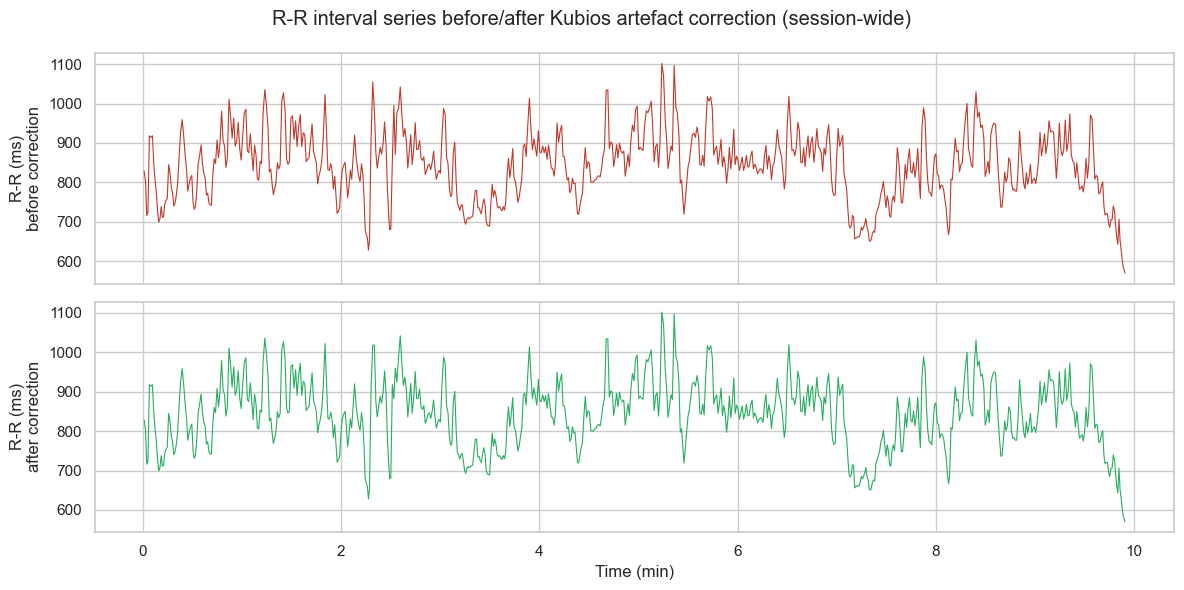

In [6]:
def correct_rr_series(rr_ms):
    # Runs the Lipponen & Tarvainen (2019) "Kubios" beat correction on one
    # array of R-R intervals (ms). Returns (corrected_rr_ms, artefact_fraction,
    # counts_by_category). intervals_to_peaks() turns the RR series into a
    # synthetic peak train (as if sampled at 1000 Hz) because signal_fixpeaks
    # operates on peak positions, not directly on intervals.
    rr_ms = np.asarray(rr_ms, dtype=float)
    n = rr_ms.size
    empty_counts = {"ectopic": 0, "missed": 0, "extra": 0, "longshort": 0}
    if n < 4:
        return rr_ms, 0.0, empty_counts
    peaks = nk.intervals_to_peaks(rr_ms, sampling_rate=1000)
    try:
        info, peaks_clean = nk.signal_fixpeaks(peaks, sampling_rate=1000, method="Kubios")
    except Exception:
        return rr_ms, 0.0, empty_counts
    counts = {k: len(info.get(k, [])) for k in empty_counts}
    flagged_idx = set()
    for k in empty_counts:
        flagged_idx.update(np.asarray(info.get(k, [])).astype(int).tolist())
    frac = len(flagged_idx) / max(1, n)
    rr_corrected = np.diff(np.asarray(peaks_clean, dtype=float))   # ms, since sampling_rate=1000
    return rr_corrected, frac, counts


rr_events = sorted([e for e in events if e.get("sensor") == "hr_rr"], key=lambda e: e["ts"])
if not rr_events:
    raise RuntimeError("No hr_rr events - Polar H10 R-R data missing")
_rr_all = np.array([e["value"] for e in rr_events], dtype=float)

_rr_corrected_all, _frac_all, _counts_all = correct_rr_series(_rr_all)
print("Session-wide artefact summary (descriptive only - the label rule uses per-window correction):")
_total = _rr_all.size
for k, v in _counts_all.items():
    print(f"  {k:<10}: {v:>5}  ({100*v/max(1,_total):.2f}% of {_total} beats)")
print(f"  any category : {100*_frac_all:.2f}% of beats flagged")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(np.cumsum(_rr_all) / 1000 / 60, _rr_all, color="#c0392b", lw=0.8)
axes[0].set_ylabel("R-R (ms)\nbefore correction")
axes[1].plot(np.cumsum(_rr_corrected_all) / 1000 / 60, _rr_corrected_all, color="#27ae60", lw=0.8)
axes[1].set_ylabel("R-R (ms)\nafter correction")
axes[1].set_xlabel("Time (min)")
fig.suptitle("R-R interval series before/after Kubios artefact correction (session-wide)")
plt.tight_layout(); plt.show()

### Window generation

Every window is a fixed-length slice `[start, start + WIN_S)` of the
continuous session. Two grids are built from the same session bounds:

- the **analysis grid** (`STEP_S = 5` s step) overlaps by 83% and exists only
  for the inspection plots in Section 4.13 and the `labelled_windows_overlapping.csv`
  export;
- the **ML grid** (`STEP_S_EXPORT = WIN_S`, i.e. no overlap) is the one used
  for calibration (Section 4.7) and for training data (Section 4.9), because
  overlapping windows share up to 83% of their raw samples and are not
  independent observations.

In [7]:
def build_windows(t0_ms, t1_ms, win_s, step_s):
    win_ms, step_ms = int(win_s * 1000), int(step_s * 1000)
    starts = []
    s = t0_ms
    while s + win_ms <= t1_ms:
        starts.append(s)
        s += step_ms
    return [(a, a + win_ms) for a in starts]


ANALYSIS_WINDOWS = build_windows(T0_MS, SESSION_T1_MS, WIN_S, STEP_S)
ML_WINDOWS = build_windows(T0_MS, SESSION_T1_MS, WIN_S, STEP_S_EXPORT)

print(f"Analysis grid (overlapping, step={STEP_S}s): {len(ANALYSIS_WINDOWS)} windows")
print(f"ML grid (non-overlapping, step={STEP_S_EXPORT}s): {len(ML_WINDOWS)} windows")

if len(ML_WINDOWS) < MIN_ML_WINDOWS:
    raise RuntimeError(
        f"Session yields only {len(ML_WINDOWS)} non-overlapping window(s); "
        f"need at least {MIN_ML_WINDOWS} for the median/MAD calibration in §4.7 to be meaningful.")

Analysis grid (overlapping, step=5s): 115 windows
ML grid (non-overlapping, step=30s): 20 windows


## 4.5 HRV features per window

For every window we compute:

- **RMSSD** (root mean square of successive differences) — the primary
  time-domain measure used to estimate vagally mediated changes in HRV
  (Shaffer & Ginsberg, 2017, "RMSSD").
- **mean HR** (heart rate, beats per minute).
- **SDNN** (standard deviation of the intervals) and **pNN50** (percentage of
  successive differences greater than 50 ms) — kept as descriptive features,
  not used in the label rule.
- **n_beats** — the number of corrected beats found in the window.

**Honest caveats, stated plainly, not hidden:**

- *Ultra-short-term values are not interchangeable with 5-min or 24-h
  values* (Shaffer & Ginsberg, 2017, "Summary"). A 30-second RMSSD is a
  different quantity, statistically, from the 5-minute RMSSD the rest of the
  HRV literature usually reports.
- *Respiration was not recorded in this study.* Shaffer & Ginsberg (2017,
  "HF Power and RSA do not Represent Vagal Tone") state that shifts in
  respiration rate and volume change RMSSD **without** changing vagal tone.
  This is an acknowledged, uncontrolled confounder in every RMSSD value below
  — we do not claim RMSSD is robust to breathing, because the source we rely
  on for RMSSD says the opposite.
- *RMSSD is never used to decide valence direction, and this is not just
  caution.* Kreibig (2010) found that HRV increased in some positive
  emotions (amusement, joy) but decreased in others (happiness), while
  contamination-related disgust — a negative emotion — was the only one
  associated with *increased* vagal influence: direction does not track
  valence. Schneider et al. (2025), reviewing 36 studies (N = 5,501), found
  associations between positive affect and RMSSD that vary by context, not a
  single consistent direction. Schippers et al. (2018), using the same
  30-second-window RMSSD and IAPS picture-induction design as this notebook,
  found **no significant RMSSD difference between positive and negative
  emotion induction at all**. All three point the same way: RMSSD is not a
  usable valence signal at any window length tested so far.

**A quality gate, not a filter.** Nunan et al. (2010), as reproduced in
Shaffer & Ginsberg (2017, Table 6), report a short-term RMSSD range of
19-75 ms (mean 42, SD 15) across published studies. Below we report what
fraction of our windows fall outside that range, purely as a descriptive
flag (`rmssd_outside_norm_range`). We do **not** treat values above 100 ms as
"physiologically implausible" and do **not** use this as an exclusion filter
— the actual quality gate is the per-beat artefact fraction from Section 4.3.

In [8]:
def compute_hrv_features_for_windows(windows, rr_events):
    ts = np.array([e["ts"] for e in rr_events], dtype=np.int64)
    val = np.array([e["value"] for e in rr_events], dtype=float)
    order = np.argsort(ts)
    ts, val = ts[order], val[order]

    rows = []
    for a, b in windows:
        m = (ts >= a) & (ts < b)
        rr_raw = val[m]
        n_raw = int(rr_raw.size)
        if n_raw < HRV_MIN_BEATS:
            rows.append(dict(win_start_ms=a, win_end_ms=b, rmssd=np.nan, mean_hr=np.nan,
                              sdnn=np.nan, pnn50=np.nan, n_beats=n_raw, artefact_fraction=np.nan,
                              hrv_quality="poor", hrv_exclude_reason="insufficient_beats"))
            continue
        rr_corr, frac, counts = correct_rr_series(rr_raw)
        if rr_corr.size < 2:
            rows.append(dict(win_start_ms=a, win_end_ms=b, rmssd=np.nan, mean_hr=np.nan,
                              sdnn=np.nan, pnn50=np.nan, n_beats=int(rr_corr.size),
                              artefact_fraction=round(float(frac), 4), hrv_quality="poor",
                              hrv_exclude_reason="insufficient_beats_after_correction"))
            continue
        diff = np.diff(rr_corr)
        rmssd = float(np.sqrt(np.mean(diff ** 2)))
        mean_hr = float(60_000.0 / np.mean(rr_corr))
        sdnn = float(np.std(rr_corr, ddof=1))
        pnn50 = float(np.mean(np.abs(diff) > 50) * 100)
        quality = "poor" if frac > HRV_ARTEFACT_FRACTION_MAX else "ok"
        reason = "artefact_fraction_exceeded" if quality == "poor" else ""
        rows.append(dict(win_start_ms=a, win_end_ms=b, rmssd=rmssd, mean_hr=mean_hr, sdnn=sdnn,
                          pnn50=pnn50, n_beats=int(rr_corr.size), artefact_fraction=round(float(frac), 4),
                          hrv_quality=quality, hrv_exclude_reason=reason))
    return pd.DataFrame(rows)


hrv_ml = compute_hrv_features_for_windows(ML_WINDOWS, rr_events)
hrv_analysis = compute_hrv_features_for_windows(ANALYSIS_WINDOWS, rr_events)

_lo, _hi = RMSSD_NUNAN_RANGE_MS
_valid_rmssd = hrv_ml["rmssd"].dropna()
_outside = ((_valid_rmssd < _lo) | (_valid_rmssd > _hi)).mean() if len(_valid_rmssd) else np.nan
hrv_ml["rmssd_outside_norm_range"] = (hrv_ml["rmssd"] < _lo) | (hrv_ml["rmssd"] > _hi)

print(f"ML-grid HRV windows       : {len(hrv_ml)}")
print(f"hrv_quality == 'poor'     : {(hrv_ml.hrv_quality=='poor').sum()} "
      f"({100*(hrv_ml.hrv_quality=='poor').mean():.1f}%)")
print(f"RMSSD outside Nunan range : {100*_outside:.1f}% of valid windows "
      f"(descriptive flag only, range {_lo}-{_hi} ms)")
hrv_ml.describe()[["rmssd", "mean_hr", "sdnn", "pnn50", "artefact_fraction"]]

ML-grid HRV windows       : 20
hrv_quality == 'poor'     : 0 (0.0%)
RMSSD outside Nunan range : 5.0% of valid windows (descriptive flag only, range 19.0-75.0 ms)


,rmssd,mean_hr,sdnn,pnn50,artefact_fraction
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,48.532143,71.698219,70.999066,25.638270,0.008125
std,11.715413,4.183774,16.451316,10.157733,0.012792
min,25.890211,65.499949,26.990591,0.000000,0.000000
25%,40.610936,68.749553,62.872084,17.873303,0.000000
50%,47.852810,70.307630,73.756218,25.357143,0.000000
75%,51.524460,74.034614,75.952112,33.571429,0.024100
max,76.980936,80.661027,94.330155,45.161290,0.030300


## 4.6 Facial expression features per window

**Face detection: MTCNN, not a Haar cascade.** HSEmotion's published
accuracies are reported on subsets of AffectNet in which MTCNN detected the
facial region (EmotiEffLib repository, "Details" section): *"we report the
accuracies for AFEW and VGAF only on the subsets, in which MTCNN detects
facial regions"* — no other detector's accuracy is documented there. Using a
different detector (e.g. a Haar cascade, or a faster modern alternative)
would run the model outside the only domain its accuracy was ever measured
on, so we use `facenet-pytorch`'s MTCNN implementation here, not a faster
substitute.

**MTCNN is still the bottleneck, so we make MTCNN itself faster, not swap
it out.** On CPU, single-frame MTCNN detection measured ~50ms/frame on real
session video (varies by machine); at 5 windows/s sampling over a 10-minute
session that is minutes of wall-clock time on its own. Three changes cut
this without changing which detector is used or how it is evaluated:
(1) `min_face_size` is raised from the default 20px to 60px — these are
seated, camera-facing recordings where the face is never that small, so
MTCNN can skip scanning the finest pyramid scales; (2) detection itself runs
on a **half-resolution** copy of the frame (`cv2.resize`, scale 0.5), with
the returned box coordinates scaled back up to crop the *original*,
full-resolution frame for the actual HSEmotion inference - only the search
for the face is cheaper, the pixels handed to the emotion model are
unchanged; (3) sampled frames are detected in **batches** of
`MTCNN_BATCH_SIZE` (default 64) rather than one call per frame - measured
~2x faster again on top of (1) and (2), since a single batched call
amortises PyTorch's per-call overhead across many frames instead of paying
it every frame. Batches are chunked, not one batch for the whole session, so
memory stays bounded. Checked directly against full-resolution,
one-at-a-time detection on real session video before adopting (1)+(2): same
detection rate (77/77 frames), median IoU 0.918 between the full-res and
downscaled boxes - detection quality is preserved. HSEmotion is not
batched - crop sizes vary per frame, and it was already fast (~20ms/frame)
relative to MTCNN.

**Model: `enet_b0_8_va_mtl`** (Savchenko, 2022, arXiv:2203.13436), a
multi-task network that predicts, from one forward pass over a face crop, 10
raw numbers: 8 expression logits (Anger, Contempt, Disgust, Fear, Happiness,
Neutral, Sadness, Surprise) followed by valence (`scores[8]`) and arousal
(`scores[9]`).

**The `logits` argument, stated correctly.** `predict_emotions(...,
logits=True)` returns the raw model outputs. `logits=False` applies a
softmax to the **first 8 outputs only** and leaves valence and arousal
unchanged — this is visible directly in the HSEmotion source
(`hsemotion_onnx/facial_emotions.py`: `x = scores[:-2]`, softmax is computed
over `x`, and only `scores[:-2]` is overwritten). Both options are therefore
equivalent for our purposes; we use `logits=True` and compute the softmax
ourselves, so the expression probabilities and the raw regression outputs
are both explicit in the code below.

**Bounded annotations, unbounded predictions.** AffectNet's human
annotations for valence and arousal lie in [-1, +1] (Mollahosseini et al.,
2019). The *model's* regression outputs are not constrained to that range —
nothing in a neural network's output layer enforces it — so we clip every
prediction to [-1, +1] after inference.

**Per window** we compute a confidence-weighted mean valence and arousal
(frames the model is unsure about contribute less), the mean expression
confidence, the dominant expression, and `face_coverage` — the fraction of
sampled frames in the window with a detected face. Windows with
`face_coverage < 0.5` get `fer_quality = "poor"` and are excluded from
labelling (Section 4.8).

**Accuracy, stated honestly.** `enet_b0_8_va_mtl` reaches **61.93%** accuracy
on AffectNet with 8 classes (the configuration we use here; EmotiEffLib
repository model table). The 7-class number for this model family is higher
(64.94%) but does not apply to our setup, so we do not quote it. This is an
imperfect estimator of direction, which is exactly why Section 4.14 lists it
as a limitation rather than treating it as ground truth.

In [9]:
EMOTIONS = ["Anger", "Contempt", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"]

def _softmax(x):
    e = np.exp(x - np.max(x))
    return e / (e.sum() + 1e-9)


def run_video_fer(video_path, t0_ms, frame_ts_lookup, sample_hz=FER_SAMPLE_HZ,
                  detect_scale=MTCNN_DETECT_SCALE, min_face_size=MTCNN_MIN_FACE_SIZE,
                  batch_size=MTCNN_BATCH_SIZE):
    if not (CV2_OK and MTCNN_OK and HSEMOTION_OK):
        raise RuntimeError("opencv-python, facenet-pytorch and hsemotion-onnx are all required for FER on real video.")
    # min_face_size is in pixels of whatever image is actually passed to
    # detect() below - since that is the downscaled copy, the threshold must
    # be scaled down too, or it would silently require a much larger face
    # (in original-resolution terms) than MTCNN_MIN_FACE_SIZE documents.
    mtcnn = MTCNN(keep_all=False, device="cpu", min_face_size=min_face_size * detect_scale)
    fer = HSEmotionRecognizer(model_name="enet_b0_8_va_mtl")
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    step = max(1, int(round(fps / sample_hz)))
    idx, n_faces, n_sampled = 0, 0, 0
    rows = []

    # Sampled frames are batched through MTCNN.detect() together rather than
    # one at a time - measured ~2x faster on real session video, on top of
    # the downscaling above, because it amortises PyTorch's per-call overhead
    # across many images instead of paying it every single frame. Chunked
    # (not all ~3000 sampled frames in one batch) to keep memory bounded -
    # each chunk holds its full-resolution frames too, needed for the actual
    # HSEmotion crop after detection.
    chunk_full, chunk_small, chunk_ts = [], [], []

    def flush_chunk():
        nonlocal n_faces, n_sampled
        if not chunk_small:
            return
        boxes_batch, probs_batch = mtcnn.detect(np.stack(chunk_small))
        for full, boxes, probs, ts_ms in zip(chunk_full, boxes_batch, probs_batch, chunk_ts):
            n_sampled += 1
            face = None
            if boxes is not None and len(boxes) > 0:
                best = int(np.argmax(probs))
                x1, y1, x2, y2 = [int(max(0, v) / detect_scale) for v in boxes[best]]
                crop = full[y1:y2, x1:x2]
                if crop.size > 0:
                    face = crop
            if face is not None:
                n_faces += 1
                # logits=True: raw outputs. We compute the softmax ourselves
                # over the 8 expression logits only; valence/arousal (last
                # two outputs) are untouched by this choice either way (see
                # markdown). HSEmotion is not batched - crop sizes vary per
                # frame, and it is already fast relative to MTCNN.
                _, scores = fer.predict_emotions(face, logits=True)
                scores = np.asarray(scores, dtype=np.float32).flatten()
                emo_logits = scores[:8]
                val = float(np.clip(scores[8], -1.0, 1.0))
                aro = float(np.clip(scores[9], -1.0, 1.0))
                probs8 = _softmax(emo_logits)
                emo_idx = int(np.argmax(probs8))
                rows.append({"ts": int(ts_ms), "emotion": EMOTIONS[emo_idx],
                             "valence": round(val, 3), "arousal": round(aro, 3),
                             "confidence": round(float(probs8.max()), 3)})
            else:
                rows.append({"ts": int(ts_ms), "emotion": None, "valence": None,
                             "arousal": None, "confidence": 0.0})
        chunk_full.clear(); chunk_small.clear(); chunk_ts.clear()

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % step == 0:
            ts_ms = frame_ts_lookup.get(idx, t0_ms + (idx / fps) * 1000)
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # Detect on a downscaled copy (cheaper for MTCNN's pyramid scan),
            # then scale the box back up and crop from the full-resolution
            # frame - only the search is cheaper, not what HSEmotion sees.
            h, w = rgb.shape[:2]
            small = cv2.resize(rgb, (max(1, int(w * detect_scale)), max(1, int(h * detect_scale))))
            chunk_full.append(rgb); chunk_small.append(small); chunk_ts.append(ts_ms)
            if len(chunk_small) >= batch_size:
                flush_chunk()
        idx += 1
    flush_chunk()
    cap.release()
    print(f"FER on video: {n_sampled} frames sampled, {n_faces} with a detected face "
          f"({100*n_faces/max(1,n_sampled):.1f}% coverage overall)")
    return rows


if FER_STORE.exists():
    print(f"Loading cached FER data from {FER_STORE.name} ...")
    fer_rows = load_events(FER_STORE)
elif VIDEO_FILE.exists():
    print("Computing FER from video (MTCNN + HSEmotion enet_b0_8_va_mtl) ...")
    frame_lookup = {int(e["value"]): e["ts"] for e in events if e.get("sensor") == "camera_frame"}
    fer_rows = run_video_fer(VIDEO_FILE, T0_MS, frame_lookup, FER_SAMPLE_HZ)
    FER_STORE.write_text("\n".join(json.dumps(r) for r in fer_rows), encoding="utf-8")
else:
    print("WARNING: no video available - FER disabled. Every window will be excluded "
          "for missing_data because the label rule requires a facial valence direction.")
    fer_rows = []

print(f"FER rows: {len(fer_rows)}")

Computing FER from video (MTCNN + HSEmotion enet_b0_8_va_mtl) ...
FER on video: 2851 frames sampled, 2652 with a detected face (93.0% coverage overall)
FER rows: 2851


In [10]:
def compute_fer_features_for_windows(windows, fer_rows):
    if not fer_rows:
        return pd.DataFrame([dict(win_start_ms=a, win_end_ms=b, fer_valence=np.nan, fer_arousal=np.nan,
                                   fer_confidence=0.0, fer_dominant_emotion=None, face_coverage=0.0,
                                   fer_n=0, fer_quality="poor", fer_exclude_reason="no_video")
                              for a, b in windows])
    ts = np.array([r["ts"] for r in fer_rows], dtype=np.int64)
    order = np.argsort(ts)
    ts = ts[order]
    rows_sorted = [fer_rows[i] for i in order]

    out = []
    for a, b in windows:
        idx = np.where((ts >= a) & (ts < b))[0]
        sub = [rows_sorted[i] for i in idx]
        n_sampled = len(sub)
        with_face = [r for r in sub if r.get("valence") is not None]
        coverage = (len(with_face) / n_sampled) if n_sampled > 0 else 0.0
        if with_face:
            wts = np.array([r["confidence"] for r in with_face], dtype=float)
            wsum = wts.sum()
            wn = wts / wsum if wsum > 0 else np.ones_like(wts) / len(wts)
            val = float(np.clip((np.array([r["valence"] for r in with_face]) * wn).sum(), -1, 1))
            aro = float(np.clip((np.array([r["arousal"] for r in with_face]) * wn).sum(), -1, 1))
            conf_mean = float(wts.mean())
            dom = Counter(r["emotion"] for r in with_face).most_common(1)[0][0]
        else:
            val = aro = np.nan
            conf_mean = 0.0
            dom = None
        quality = "poor" if coverage < FER_COVERAGE_MIN else "ok"
        reason = "low_face_coverage" if quality == "poor" else ""
        out.append(dict(win_start_ms=a, win_end_ms=b, fer_valence=val, fer_arousal=aro,
                         fer_confidence=conf_mean, fer_dominant_emotion=dom,
                         face_coverage=round(coverage, 4), fer_n=n_sampled,
                         fer_quality=quality, fer_exclude_reason=reason))
    return pd.DataFrame(out)


fer_ml = compute_fer_features_for_windows(ML_WINDOWS, fer_rows)
fer_analysis = compute_fer_features_for_windows(ANALYSIS_WINDOWS, fer_rows)

print(f"ML-grid FER windows   : {len(fer_ml)}")
print(f"fer_quality == 'poor' : {(fer_ml.fer_quality=='poor').sum()} "
      f"({100*(fer_ml.fer_quality=='poor').mean():.1f}%)")
fer_ml.describe()[["fer_valence", "fer_arousal", "fer_confidence", "face_coverage"]]

ML-grid FER windows   : 20
fer_quality == 'poor' : 2 (10.0%)


,fer_valence,fer_arousal,fer_confidence,face_coverage
count,19.000000,19.000000,20.000000,20.000000
mean,-0.047481,-0.098914,0.532787,0.884000
std,0.265182,0.116046,0.140333,0.271168
min,-0.360098,-0.366296,0.000000,0.000000
25%,-0.225840,-0.157951,0.517592,0.966675
50%,-0.095220,-0.122514,0.550503,1.000000
75%,0.003539,-0.029761,0.579461,1.000000
max,0.557419,0.133826,0.724107,1.000000


## 4.7 Per-participant calibration

There is no resting baseline phase used here (this pipeline does not rely on
one). Instead, every threshold below is calibrated against the participant's
**own session-wide distribution**, using the median and the MAD (median
absolute deviation, scaled by 1.4826 so it estimates the standard deviation
the way a normal distribution would). This absorbs any systematic offset —
e.g. a camera angle that makes this participant's neutral face look slightly
positive to the model — without needing a separate resting recording.

All calibration statistics are computed on the **ML grid** (non-overlapping
windows), not the overlapping analysis grid: computing a median/MAD from
83%-overlapping windows would pseudo-replicate the same raw samples many
times over and understate how much true, independent variation there is.
The resulting thresholds are then applied identically to both grids.

**Valence threshold (τ), no baseline, centered on this session's own
median.**
$$\tau = k \cdot \big(1.4826 \cdot \mathrm{MAD}(\text{fer\_valence}_{\text{session}})\big), \quad k = 0.75$$
$$\text{direction} = \begin{cases}\text{positive} & \text{fer\_valence} > \text{median}_{\text{session}} + \tau \\ \text{negative} & \text{fer\_valence} < \text{median}_{\text{session}} - \tau \\ \text{neutral} & \text{otherwise}\end{cases}$$
`τ` sets what counts as "clearly outside this participant's typical
facial-expression range" during the recording - but *outside*, checked
against this session's own median, not against absolute zero. This matters:
HSEmotion's valence output for a resting face is not guaranteed to sit at
0 - it can carry a per-participant, per-camera-angle offset (checked
against four real sessions: session-wide median valence ranged from -0.269
to +0.520). A threshold checked against zero rather than the median
inherits that offset directly - a participant whose resting face reads
negative would see far more windows cross below `-τ` than above `+τ`
regardless of anything that happened during the recording, and a
participant whose resting face reads positive would see the opposite,
possibly never producing a single "negative" window. Centering on the
median is what this section already claimed to do ("absorbs any systematic
offset... without needing a separate resting recording") - the MAD term
already did that for τ's *width*, this centers the decision itself the same
way. `k = 0.75` is a **pragmatic** choice (history: `1.5` labelled almost
every window "neutral" via `face_ambiguous` on real sessions, too
conservative to be useful downstream; lowered to `1.0`, then to `0.75` so
smaller deviations from a participant's own median count as a real shift);
Section 4.10 (V4) shows how the results change for `k ∈ {0.5, 0.75, 1.0}`.

**Arousal index from HRV, no baseline.**
$$z_{\text{rmssd}} = \frac{\text{rmssd} - \text{median}_{\text{session}}}{1.4826 \cdot \text{MAD}_{\text{session}}}, \qquad
z_{\text{hr}} = \frac{\text{mean\_hr} - \text{median}_{\text{session}}}{1.4826 \cdot \text{MAD}_{\text{session}}}$$
$$\text{arousal\_hrv} = \frac{-z_{\text{rmssd}} + z_{\text{hr}}}{2}$$
RMSSD is inverted because it **decreases** with activation (vagal withdrawal;
Shaffer & Ginsberg, 2017), while HR **increases** with activation (Kreibig,
2010). Median/MAD scaling keeps a handful of extreme windows from dominating
the estimate.

**What changes without a baseline.** A uniformly calm session will produce
uniformly low `arousal_hrv` values — because the index is relative to *this*
session's own spread, not to a resting reference. That is a legitimate
outcome of this design, not a bug: without a resting-state recording, there
is no absolute reference to compare against, only the session's own
variation.

**Arousal axis: fusing HRV and facial arousal.**
Facial arousal (`fer_arousal`, §4.6) is standardised the same way, against
this session's own median and MAD:
$$z_{\text{fer\_arousal}} = \frac{\text{fer\_arousal} - \text{median}_{\text{session}}(\text{fer\_arousal})}{1.4826 \cdot \mathrm{MAD}_{\text{session}}(\text{fer\_arousal})}$$
The two standardised arousal estimates are then averaged into a single
index:
$$\text{arousal\_combined} = \frac{\text{arousal\_hrv} + z_{\text{fer\_arousal}}}{2}$$
Averaging two estimators of the same construct (activation) is an
application of convergent validity (Soleymani et al., 2016), the same
framing already used for the agreement term below. Whether HRV actually
contributes anything to this average beyond what FER arousal already
carries is not assumed — it is the question Section 4.10 (V0) tests
directly on this project's own pooled data; if HRV turns out not to
correlate with FER arousal there, `arousal_combined` falls back to
`fer_arousal` alone (§4.10 explains the fallback).

**Arousal split, at this session's own median.**
$$\text{arousal\_level} = \begin{cases}\text{activated} & \text{arousal\_combined} \ge \text{median}_{\text{session}}(\text{arousal\_combined}) \\ \text{calm} & \text{otherwise}\end{cases}$$
The split sits at the 50th percentile, not at a tail threshold such as
`+k · SD`. This is a **pragmatic** choice, but not an arbitrary one:
`arousal_combined` is built from two quantities that are each already
centered on their own session median, so it is itself centered at
(approximately) zero by construction. A `+1 SD` cutoff on a distribution
centered at zero puts the bulk of its mass below the cutoff for any
session, independent of what happened during the recording — with a
single-sided tail threshold of this kind, this put roughly 84% of
quality-ok windows on one side unconditionally, regardless of the data.
The median split does not have this property: by definition, it divides
the session's own windows in half, whatever their actual distribution
looks like.

In [ ]:
def fit_calibration(ml_df, k_tau=K_TAU):
    valid = ml_df.dropna(subset=["rmssd", "mean_hr"])
    med_rmssd = valid.rmssd.median()
    mad_rmssd = max(1e-9, 1.4826 * (valid.rmssd - med_rmssd).abs().median())
    med_hr = valid.mean_hr.median()
    mad_hr = max(1e-9, 1.4826 * (valid.mean_hr - med_hr).abs().median())

    fer_ok = ml_df.loc[ml_df.fer_quality != "poor", "fer_valence"].dropna()
    med_val = fer_ok.median() if len(fer_ok) else 0.0
    mad_val = 1.4826 * (fer_ok - med_val).abs().median() if len(fer_ok) else 0.0
    tau = k_tau * mad_val

    fer_arousal_ok = ml_df.loc[ml_df.fer_quality != "poor", "fer_arousal"].dropna()
    med_fer_arousal = fer_arousal_ok.median() if len(fer_arousal_ok) else 0.0
    mad_fer_arousal = (max(1e-9, 1.4826 * (fer_arousal_ok - med_fer_arousal).abs().median())
                        if len(fer_arousal_ok) else 1e-9)

    calib = dict(median_rmssd=med_rmssd, mad_rmssd=mad_rmssd, median_hr=med_hr, mad_hr=mad_hr, tau=tau,
                median_fer_valence=med_val, median_fer_arousal=med_fer_arousal, mad_fer_arousal=mad_fer_arousal)
    tmp = apply_calibration(ml_df, calib)
    arousal_valid = tmp["arousal_hrv"].dropna()
    calib["median_arousal_hrv"] = arousal_valid.median()
    combined_valid = tmp["arousal_combined"].dropna()
    calib["median_arousal_combined"] = combined_valid.median() if len(combined_valid) else np.nan
    return calib


def apply_calibration(df, calib):
    df = df.copy()
    df["rmssd_z"] = (df["rmssd"] - calib["median_rmssd"]) / calib["mad_rmssd"]
    df["hr_z"] = (df["mean_hr"] - calib["median_hr"]) / calib["mad_hr"]
    df["arousal_hrv"] = (-df["rmssd_z"] + df["hr_z"]) / 2
    df["fer_arousal_z"] = (df["fer_arousal"] - calib["median_fer_arousal"]) / calib["mad_fer_arousal"]
    df["arousal_combined"] = (df["arousal_hrv"] + df["fer_arousal_z"]) / 2
    return df


ml_features = hrv_ml.merge(fer_ml, on=["win_start_ms", "win_end_ms"])
analysis_features = hrv_analysis.merge(fer_analysis, on=["win_start_ms", "win_end_ms"])

CALIB = fit_calibration(ml_features, k_tau=K_TAU)
ml_features = apply_calibration(ml_features, CALIB)
analysis_features = apply_calibration(analysis_features, CALIB)

print("Calibration (session-wide, ML grid):")
for k, v in CALIB.items():
    print(f"  {k:<20}: {v:.4f}" if isinstance(v, float) else f"  {k:<20}: {v}")

**Provisional weighting of the agreement term (`w4`).** The confidence score
in Section 4.8 rewards windows where the two arousal estimates agree
(`w4`). If they do not correlate at all in this session, that term carries
no real information and should not influence confidence. We cannot wait for
Section 4.10's authoritative, cross-session V1 test before computing
confidence scores here, so we run a quick same-session check now and fall
back to `w4 = 0` (folded into `w1`, so the weights still sum to 1) if the
correlation is weak or not significant. This is a **provisional, per-session
heuristic** — Section 4.10 (V0/V1) is the test that actually decides whether
the gate and the agreement term are worth keeping at all, using data pooled
across every session processed so far.

In [12]:
_pilot = ml_features[(ml_features.hrv_quality != "poor") & (ml_features.fer_quality != "poor")]
_pilot = _pilot.dropna(subset=["arousal_hrv", "fer_arousal"])
if len(_pilot) >= 5:
    _pilot_rho, _pilot_p = sp_stats.spearmanr(_pilot["arousal_hrv"], _pilot["fer_arousal"])
else:
    _pilot_rho, _pilot_p = np.nan, np.nan

W4_EFFECTIVE = W4_AGREEMENT
W1_EFFECTIVE = W1_DIRECTION_CLARITY
if np.isnan(_pilot_rho) or abs(_pilot_rho) < 0.10 or _pilot_p >= 0.10:
    W4_EFFECTIVE, W1_EFFECTIVE = 0.0, W1_DIRECTION_CLARITY + W4_AGREEMENT
    print(f"Provisional same-session check: rho={_pilot_rho:.3f} p={_pilot_p:.3f} (n={len(_pilot)}) "
          "-> too weak this session, w4 folded into w1 for this run's confidence scores.")
else:
    print(f"Provisional same-session check: rho={_pilot_rho:.3f} p={_pilot_p:.3f} (n={len(_pilot)}) "
          "-> kept, w4 used as configured.")

Provisional same-session check: rho=-0.348 p=0.157 (n=18) -> too weak this session, w4 folded into w1 for this run's confidence scores.


## 4.8 The label rule

```
For each window:

  1. QUALITY
     if hrv_quality == "poor" or fer_quality == "poor":
         label = "excluded";  reason = <which gate failed>;  stop.

  2. VALENCE DIRECTION  (from the face - Mollahosseini et al. 2019; Soleymani et al. 2016)
     if   fer_valence >  median_fer_valence + tau:  valence_direction = "positive"
     elif fer_valence <  median_fer_valence - tau:  valence_direction = "negative"
     else:                                          valence_direction = "neutral"   # reason = "face_ambiguous"

  3. AROUSAL LEVEL  (HRV + FER, fused - §4.7)
     arousal_level = "activated"  if arousal_combined >= median_arousal_combined
                      "calm"       otherwise

  4. LABEL  (Russell 1980 circumplex, crossed)
     if valence_direction == "neutral":  label = "neutral"
     else:                               label = f"{valence_direction}-{arousal_level}"
     # five classes: neutral, positive-activated, positive-calm,
     #               negative-activated, negative-calm

  5. CONFIDENCE  (convergent validity between the two arousal estimates)
     agreement = "converging"  if sign(arousal_hrv - median) == sign(fer_arousal - median)
                 "diverging"   otherwise
     confidence = w1 * min(1, |fer_valence| / tau)          # how clear is the direction
                + w2 * mean expression confidence           # how sure is the FER model
                + w3 * face_coverage                        # how much of the window had a face
                + w4 * (1 if agreement == "converging" else 0)
```

**Two axes, five classes — quadrant names, not basic emotions.** Valence and
arousal identify a *quadrant* of Russell's (1980) circumplex model of
affect, not a discrete emotion: anger and fear, for instance, are both
negative-valence, high-arousal states, and a valence/arousal label alone
cannot tell them apart. `valence_direction` comes from the face exactly as
before (Section 4.7's median-centered deadband); `arousal_level` comes from
`arousal_combined`, the fused HRV + FER arousal index from Section 4.7,
split at this session's own median. Crossing the two gives four directional
classes (`positive-activated`, `positive-calm`, `negative-activated`,
`negative-calm`), plus `neutral` whenever the face is ambiguous, regardless
of arousal.

**The arousal split needs no threshold parameter.** Unlike a tail-cutoff
design, the median split in Section 4.7 has nothing analogous to a `z`
multiplier — it always divides the session's own windows into an activated
half and a calm half. The confidence weights `w1..w4` remain pragmatic
choices, not literature-derived; Section 4.10 (V4) shows how sensitive the
results are to `k` and `WIN_S`.

**Convergent validity, not "independent raters".** Both HSEmotion
(`fer_arousal`) and HRV (`arousal_hrv`) estimate the same construct
(activation), so comparing them is a convergent-validity check, not two
independent measurements. Soleymani et al. (2016) found that facial
expression outperformed a physiological signal (EEG) for continuous valence,
and that a large part of the EEG's emotional content actually came from
facial-muscle contamination — i.e. the two channels were *not* independent.
We use the same framing here: `agreement` reports whether the two arousal
estimates move together, and we report the result honestly even if it is
weak (Section 4.10, V1). If this session's own data shows no such agreement,
`w4` is provisionally set to 0 (§4.7) rather than rewarding a coincidence.

In [ ]:
def _direction_from_face(fer_valence, tau, median_valence=0.0):
    # Centered on THIS session's own median valence, not absolute zero. A
    # participant whose resting face reads negative (or positive) to the
    # model gets a fixed offset applied to every window, which a
    # zero-centered threshold does not correct for - it only requires a
    # deviation from zero, not a deviation from what is typical for this
    # participant. Centering on the median is what the calibration
    # philosophy in this section already claims to do; before this fix the
    # code only used the median to size the MAD, not to center the
    # decision, so a session with an off-zero median could see only ever
    # "positive" or only ever "negative" regardless of anything that
    # actually happened. See markdown above.
    if fer_valence > median_valence + tau:
        return "positive", "face_positive"
    if fer_valence < median_valence - tau:
        return "negative", "face_negative"
    return "neutral", "face_ambiguous"


def label_windows(df, calib,
                  w1=W1_DIRECTION_CLARITY, w2=W2_FER_CONFIDENCE,
                  w3=W3_FACE_COVERAGE, w4=W4_AGREEMENT):
    tau = calib["tau"]
    med_fer_valence = calib["median_fer_valence"]
    med_arousal_hrv = calib["median_arousal_hrv"]
    med_fer_arousal = calib["median_fer_arousal"]
    med_arousal_combined = calib["median_arousal_combined"]

    valence_directions, arousal_levels, labels = [], [], []
    reasons, confs, agreements = [], [], []
    for r in df.itertuples():
        if r.hrv_quality == "poor" or r.fer_quality == "poor":
            failed = []
            if r.hrv_quality == "poor":
                failed.append(f"hrv:{r.hrv_exclude_reason}")
            if r.fer_quality == "poor":
                failed.append(f"fer:{r.fer_exclude_reason}")
            reason = "poor_quality(" + ",".join(failed) + ")"
            valence_directions.append("excluded"); arousal_levels.append("excluded"); labels.append("excluded")
            reasons.append(reason); confs.append(0.0); agreements.append("none")
            continue
        if pd.isna(r.arousal_hrv) or pd.isna(r.fer_valence) or pd.isna(r.fer_arousal):
            valence_directions.append("excluded"); arousal_levels.append("excluded"); labels.append("excluded")
            reasons.append("missing_data"); confs.append(0.0); agreements.append("none")
            continue

        valence_direction, reason = _direction_from_face(r.fer_valence, tau, med_fer_valence)
        arousal_level = "activated" if r.arousal_combined >= med_arousal_combined else "calm"
        label = "neutral" if valence_direction == "neutral" else f"{valence_direction}-{arousal_level}"

        agreement = ("converging"
                     if np.sign(r.arousal_hrv - med_arousal_hrv) == np.sign(r.fer_arousal - med_fer_arousal)
                     else "diverging")
        direction_clarity = min(1.0, abs(r.fer_valence - med_fer_valence) / tau) if tau > 0 else 0.0
        conf = (w1 * direction_clarity + w2 * r.fer_confidence + w3 * r.face_coverage
               + w4 * (1.0 if agreement == "converging" else 0.0))

        valence_directions.append(valence_direction); arousal_levels.append(arousal_level); labels.append(label)
        reasons.append(reason); confs.append(round(float(conf), 3)); agreements.append(agreement)

    df = df.copy()
    df["valence_direction"] = valence_directions
    df["arousal_level"] = arousal_levels
    df["label"] = labels
    df["reason"] = reasons
    df["label_confidence"] = confs
    df["agreement"] = agreements
    df["label_type"] = "proxy"   # never "ground truth" - see §4.0
    return df


ml_df = label_windows(ml_features, CALIB, w4=W4_EFFECTIVE, w1=W1_EFFECTIVE)
analysis_df = label_windows(analysis_features, CALIB, w4=W4_EFFECTIVE, w1=W1_EFFECTIVE)

print("Valence-direction distribution (ML grid):")
print(ml_df["valence_direction"].value_counts())
print()
print("Arousal-level distribution (ML grid, non-excluded only):")
print(ml_df.loc[ml_df.label != "excluded", "arousal_level"].value_counts())
print()
print("Label distribution (ML grid):")
print(ml_df["label"].value_counts())
print()
print("Agreement categories (ML grid, non-excluded only):")
print(ml_df.loc[ml_df.label != "excluded", "agreement"].value_counts())
print()
print("Exclusion reasons (ML grid):")
print(ml_df.loc[ml_df.label == "excluded", "reason"].value_counts())

## 4.9 Exports

Two files are written:

- **`labelled_windows_overlapping.csv`** — the `STEP_S`-step grid. For
  plotting and inspection only (Section 4.13).
- **`labelled_windows_ml.csv`** — the non-overlapping `WIN_S`-step grid, one
  row per window, with `participant_id`. **Use this file for model
  training**, and split by `participant_id` (e.g. `GroupKFold`), never
  randomly. Overlapping windows share up to 83% of their raw samples; even
  the non-overlapping export still has multiple windows per participant that
  are not independent of each other in the way a random split assumes, so
  grouping by participant is the safe default for any cross-validation
  scheme built on top of this file.

Both files carry `valence_direction` and `arousal_level` alongside the
crossed `label` (Section 4.8) — five directional classes plus `excluded`.

Plant-voltage features (Section 4.12) are computed after the validation
suite and merged into both files at that point, overwriting the versions
written here — the column list below therefore does not yet include them.

In [ ]:
BASE_COLS = ["win_start_ms", "win_end_ms", "label", "valence_direction", "arousal_level",
             "label_confidence", "reason", "agreement", "label_type",
             "rmssd", "mean_hr", "sdnn", "pnn50", "n_beats", "artefact_fraction", "hrv_quality",
             "rmssd_z", "hr_z", "arousal_hrv", "rmssd_outside_norm_range",
             "fer_valence", "fer_arousal", "fer_arousal_z", "arousal_combined", "fer_confidence",
             "fer_dominant_emotion", "face_coverage", "fer_n", "fer_quality"]

def finalize_export(df, participant_id, session_id):
    out = df[[c for c in BASE_COLS if c in df.columns]].copy()
    out.insert(0, "session_id", session_id)
    out.insert(1, "participant_id", participant_id)
    return out

ml_export = finalize_export(ml_df, PARTICIPANT_ID, SESSION_ID)
overlap_export = finalize_export(analysis_df, PARTICIPANT_ID, SESSION_ID)

ml_export.to_csv(OUT_ML_CSV, index=False)
overlap_export.to_csv(OUT_OVERLAP_CSV, index=False)
print(f"Saved: {OUT_ML_CSV}  ({len(ml_export)} rows)")
print(f"Saved: {OUT_OVERLAP_CSV}  ({len(overlap_export)} rows)")

In [15]:
# ── Reconciliation: every window is accounted for ──────────────────────
n_total = len(ml_df)
n_excluded = int((ml_df.label == "excluded").sum())
n_labelled = n_total - n_excluded
assert n_labelled + n_excluded == n_total

print("Reconciliation (ML grid):")
print(f"  total windows          : {n_total}")
print(f"  labelled (not excluded): {n_labelled}")
print(f"  excluded                : {n_excluded}")
if n_excluded:
    print("  excluded, by reason:")
    for reason, n in ml_df.loc[ml_df.label == "excluded", "reason"].value_counts().items():
        print(f"    - {reason}: {n}")

Reconciliation (ML grid):
  total windows          : 20
  labelled (not excluded): 18
  excluded                : 2
  excluded, by reason:
    - poor_quality(fer:low_face_coverage): 2


## 4.10 Validation suite

No self-report exists, so we cannot measure accuracy against a known answer.
This pipeline also does not use any stimulus/clip structure (see the scope
note in Section 4.0), so a between-participant "did everyone react the same
way to the same clip" test is not available here — that would have been the
strongest test this kind of data could support, and its absence is listed as
a limitation in Section 4.14. What remains are tests that would each falsify
part of the design if it were not working, run across every session whose
`labelled_windows_ml.csv` has been written to disk so far (i.e. this session
plus any previously processed ones).

- **V0 — does HRV contribute to the arousal axis beyond FER alone?**
  Ultra-short-term HRV is a weak, contested arousal signal on its own
  (Schippers et al., 2018; Gu et al., 2023) — so we test its convergence
  with FER arousal here instead of assuming it, and use the result to
  decide whether `arousal_combined` keeps the HRV term or falls back to
  FER arousal alone.
- **V1 — convergent validity.** Do the two arousal estimates (HRV-based and
  face-based) move together, as two measurements of the same construct
  should?
- **V3 — negative control.** If we destroy the real temporal pairing between
  the face and the heart (by shuffling FER windows in time within each
  participant), does V1's correlation collapse toward zero, as it should if
  it reflects genuine convergence rather than a shared slow trend or an
  artefact of the pipeline?
- **V4 — sensitivity analysis.** How much do the label distribution and the
  V1 statistic change across the grid of pragmatic parameter choices
  (`k`, `WIN_S`)? Conclusions that only hold at one parameter setting are
  not conclusions.

In [16]:
def load_all_ml_exports(root):
    files = sorted(Path(root).glob("*/labelled_windows_ml.csv")) if Path(root).exists() else []
    if SESSION_DIR.name not in [f.parent.name for f in files] and OUT_ML_CSV.exists():
        files.append(OUT_ML_CSV)
    frames = []
    for f in files:
        try:
            frames.append(pd.read_csv(f))
        except Exception as e:
            print(f"  skipping {f}: {e}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


_agg_root = SESSIONS_ROOT
all_ml = load_all_ml_exports(_agg_root)
n_participants = all_ml["participant_id"].nunique() if len(all_ml) else 0
print(f"Cross-session aggregation: {n_participants} participant(s), {len(all_ml)} total ML windows "
      f"found on disk under {_agg_root}.")
if n_participants < 2:
    print("Only one participant's export is available. Run this notebook on more sessions "
          "(via SESSION_DIR_OVERRIDE) to accumulate more before V0/V1/V3 become informative "
          "across participants.")

Cross-session aggregation: 1 participant(s), 20 total ML windows found on disk under ..\data\sessions.
Only one participant's export is available. Run this notebook on more sessions (via SESSION_DIR_OVERRIDE) to accumulate more before V0/V1/V3 become informative across participants.


### V0 — Does HRV contribute to the arousal axis beyond FER alone?

Section 4.7 fuses two arousal estimators (HRV-based `arousal_hrv` and
facial `fer_arousal`) into `arousal_combined`. Whether HRV actually adds
anything to that average is not assumed — ultra-short-term HRV is a weak,
contested arousal signal on its own (Schippers et al., 2018; Gu et al.,
2023). We test it directly: the pooled Spearman correlation between
`arousal_hrv` and `fer_arousal`, across every quality-ok window from every
session processed so far.

**What a pass looks like:** the pooled correlation is statistically
significant (`p < 0.05`) and positive — evidence the two channels are
picking up the same underlying activation, supporting the fusion in
Section 4.7. **What a fail looks like:** the correlation is not significant,
or not positive — evidence HRV is not contributing real information to the
arousal axis here. In that case `arousal_combined` falls back to
`fer_arousal` alone for this dataset, and the HRV contribution is reported
as not supported rather than assumed. Either outcome is a valid, reportable
result — "HRV doesn't help here" is not a failure of the notebook, it is
exactly the kind of thing V0 exists to catch.

In [ ]:
def pooled_spearman_on(df, exclude_labelled=False):
    # exclude_labelled=True drops rows already marked "excluded" - used by
    # V0/V1/V4 below, which all pass the full aggregate directly.
    if exclude_labelled:
        df = df[df.label != "excluded"]
    gg = df.dropna(subset=["arousal_hrv", "fer_arousal"])
    if len(gg) < 5:
        return np.nan, np.nan, len(gg)
    rho, p = sp_stats.spearmanr(gg["arousal_hrv"], gg["fer_arousal"])
    return rho, p, len(gg)


if len(all_ml):
    rho_v0, p_v0, n_v0 = pooled_spearman_on(all_ml, exclude_labelled=True)
    print(f"Pooled arousal_hrv <-> fer_arousal (all quality-ok windows): "
          f"rho={rho_v0:.3f}  p={p_v0:.4f}  n={n_v0}")

    HRV_CONTRIBUTES = n_v0 >= 5 and not np.isnan(p_v0) and p_v0 < 0.05 and rho_v0 > 0
    if HRV_CONTRIBUTES:
        print("\nV0 verdict: HRV correlates significantly and positively with FER arousal on "
              "this project's pooled data -> arousal_combined keeps both terms.")
    else:
        print("\nV0 verdict: no significant positive correlation between HRV and FER arousal on "
              "this project's pooled data -> HRV's contribution to the arousal axis is not "
              "supported here, consistent with Schippers et al. (2018) and Gu et al. (2023) -> "
              "arousal_combined falls back to FER arousal alone.")
else:
    HRV_CONTRIBUTES = True
    print("Not enough aggregated data yet to run V0.")

# Apply V0's verdict to this session's own working frames: arousal_combined
# and the label derived from it were computed with the fused index at
# labelling time (§4.8), before V0 could run. §4.12 re-saves both CSVs after
# adding plant features, so this also fixes what ends up on disk.
if not HRV_CONTRIBUTES:
    ml_df["arousal_combined"] = ml_df["fer_arousal_z"]
    analysis_df["arousal_combined"] = analysis_df["fer_arousal_z"]
    CALIB["median_arousal_combined"] = ml_df.loc[ml_df.label != "excluded", "arousal_combined"].median()
    ml_df = label_windows(ml_df, CALIB, w4=W4_EFFECTIVE, w1=W1_EFFECTIVE)
    analysis_df = label_windows(analysis_df, CALIB, w4=W4_EFFECTIVE, w1=W1_EFFECTIVE)
    print("\narousal_combined and label (this session) recomputed from fer_arousal_z alone.")

### V1 — Convergent validity of the two arousal estimates

Per participant, we compute the Spearman correlation between `arousal_hrv`
and `fer_arousal` across that participant's non-excluded windows.

**What a pass looks like:** a positive correlation, broadly consistent
across participants — evidence the two channels are picking up the same
underlying activation.
**What a fail looks like:** correlations near zero or inconsistent in sign
across participants — evidence the two channels disagree about activation.
That would **not** invalidate the valence label (which comes from the face
alone, never from HRV), but it would mean the agreement term `w4` in the
confidence score is carrying no real information and should be reconsidered.

In [18]:
def per_participant_v1(df):
    rows = []
    for pid, g in df.groupby("participant_id"):
        rho, p, n = pooled_spearman_on(g, exclude_labelled=True)
        rows.append({"participant_id": pid, "n_windows": n, "rho": rho, "p_value": p})
    return pd.DataFrame(rows)


v1_per_participant = per_participant_v1(all_ml) if len(all_ml) else pd.DataFrame()
print("V1 per participant:")
print(v1_per_participant)

v1_pooled_rho, v1_pooled_p, v1_pooled_n = (pooled_spearman_on(all_ml, exclude_labelled=True)
                                            if len(all_ml) else (np.nan, np.nan, 0))
print(f"\nV1 pooled across all participants (ignores participant structure): "
      f"rho={v1_pooled_rho:.3f}, p={v1_pooled_p:.4f}, n={v1_pooled_n}" if v1_pooled_n
      else "\nV1 pooled: not enough data.")
if len(v1_per_participant) and v1_per_participant["rho"].notna().any():
    print(f"Mean of per-participant rho: {v1_per_participant['rho'].mean():.3f}")

V1 per participant:
  participant_id  n_windows       rho   p_value
0     proband_15         18 -0.347781  0.157308

V1 pooled across all participants (ignores participant structure): rho=-0.348, p=0.1573, n=18
Mean of per-participant rho: -0.348


### V3 — Negative control (falsification test)

We shuffle, within each participant, the *pairing* between FER windows
(`fer_valence`, `fer_arousal`, `fer_confidence` moved together as a block)
and their original time position, keeping HRV untouched. This preserves
every marginal distribution (the same valence/arousal values occur the same
number of times) but destroys any real temporal correspondence between the
face and the heart. If V1's pooled correlation is genuine convergent
validity, it must collapse toward zero under this permutation. If it does
not collapse, the real V1 correlation is more likely an artefact (e.g. of a
shared slow trend such as fatigue drift) than evidence of real synchrony.

We run 5,000 permutations and report the real statistic against the null
distribution with an empirical two-sided p-value, exactly as prescribed for
this kind of falsification test.

Real pooled V1 rho          : -0.348
Permutation null (n=5000): mean=-0.001, sd=0.249
Empirical two-sided p-value : 0.1686


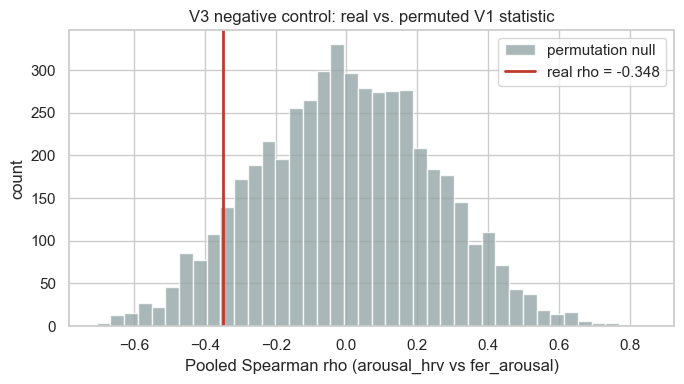


Label distribution, real data vs one permuted draw (descriptive only):
           real  one_permutation
label                           
neutral   0.889            0.889
negative  0.056            0.056
positive  0.056            0.056


In [19]:
def permute_fer_block_in_time(df, rng):
    out = []
    for pid, g in df.groupby("participant_id"):
        g = g.sort_values("win_start_ms").reset_index(drop=True)
        perm = rng.permutation(len(g))
        g = g.copy()
        for col in ["fer_valence", "fer_arousal", "fer_confidence"]:
            g[col] = g[col].values[perm]
        out.append(g)
    return pd.concat(out, ignore_index=True)


N_PERM = 5000
if len(all_ml) and v1_pooled_n >= 5:
    perm_rhos = np.empty(N_PERM)
    for i in range(N_PERM):
        perm_rhos[i], _, _ = pooled_spearman_on(permute_fer_block_in_time(all_ml, rng), exclude_labelled=True)
    perm_rhos = perm_rhos[~np.isnan(perm_rhos)]
    p_value_v3 = float(np.mean(np.abs(perm_rhos) >= abs(v1_pooled_rho))) if perm_rhos.size else np.nan

    print(f"Real pooled V1 rho          : {v1_pooled_rho:.3f}")
    print(f"Permutation null (n={perm_rhos.size}): mean={np.nanmean(perm_rhos):.3f}, "
          f"sd={np.nanstd(perm_rhos):.3f}")
    print(f"Empirical two-sided p-value : {p_value_v3:.4f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(perm_rhos, bins=40, color="#95a5a6", alpha=0.8, label="permutation null")
    ax.axvline(v1_pooled_rho, color="#c0392b", lw=2, label=f"real rho = {v1_pooled_rho:.3f}")
    ax.set_xlabel("Pooled Spearman rho (arousal_hrv vs fer_arousal)")
    ax.set_ylabel("count"); ax.legend(); ax.set_title("V3 negative control: real vs. permuted V1 statistic")
    plt.tight_layout(); plt.show()

    _real_dist = all_ml.loc[all_ml.label != "excluded", "label"].value_counts(normalize=True)
    _perm_dist = permute_fer_block_in_time(all_ml, rng)
    _perm_dist = _perm_dist.loc[_perm_dist.label != "excluded", "label"].value_counts(normalize=True)
    print("\nLabel distribution, real data vs one permuted draw (descriptive only):")
    print(pd.DataFrame({"real": _real_dist, "one_permutation": _perm_dist}).fillna(0).round(3))
else:
    print("Not enough data for V3 (need >=5 non-excluded windows across participants).")
    p_value_v3 = np.nan

### V4 — Sensitivity analysis

We recompute the label distribution and the V1 statistic across the grid
`k ∈ {0.5, 0.75, 1.0} × WIN_S ∈ {30, 45, 60}` for the **current session**,
re-deriving windows, features and the data-derived arousal median at each
combination (this is cheap: it re-slices the already-computed R-R and FER
data, it does not re-run video/MTCNN/HSEmotion inference). Conclusions that
survive only at one corner of this grid are not conclusions — they are an
artefact of that specific parameter choice. The arousal split itself is a
median, not a tuned threshold, so this grid only needs to vary `k` (the
valence deadband) and `WIN_S`.

In [ ]:
K_GRID = [0.5, 0.75, 1.0]
WIN_GRID = [30, 45, 60]

v4_rows = []
for win_s in WIN_GRID:
    windows_g = build_windows(T0_MS, SESSION_T1_MS, win_s, win_s)   # non-overlapping at this WIN_S
    if len(windows_g) < MIN_ML_WINDOWS:
        continue
    hrv_g = compute_hrv_features_for_windows(windows_g, rr_events)
    fer_g = compute_fer_features_for_windows(windows_g, fer_rows)
    feats_g = hrv_g.merge(fer_g, on=["win_start_ms", "win_end_ms"])

    for k in K_GRID:
        calib_g = fit_calibration(feats_g, k_tau=k)
        feats_g_cal = apply_calibration(feats_g, calib_g)
        lab_g = label_windows(feats_g_cal, calib_g)
        dist = lab_g["label"].value_counts(normalize=True).to_dict()
        rho_g, _, _ = pooled_spearman_on(lab_g, exclude_labelled=True)
        v4_rows.append({"win_s": win_s, "k": k,
                        "frac_positive_activated": dist.get("positive-activated", 0.0),
                        "frac_positive_calm": dist.get("positive-calm", 0.0),
                        "frac_neutral": dist.get("neutral", 0.0),
                        "frac_negative_activated": dist.get("negative-activated", 0.0),
                        "frac_negative_calm": dist.get("negative-calm", 0.0),
                        "frac_excluded": dist.get("excluded", 0.0),
                        "v1_rho": rho_g})

v4_df = pd.DataFrame(v4_rows)
v4_df

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
pivot = v4_df.pivot(index="k", columns="win_s", values="v1_rho")
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("V1 rho (this session) across k x WIN_S")
plt.tight_layout(); plt.show()

print("Label-distribution range across the full grid (this session):")
for col in ["frac_positive_activated", "frac_positive_calm", "frac_neutral",
            "frac_negative_activated", "frac_negative_calm", "frac_excluded"]:
    print(f"  {col:<24}: {v4_df[col].min():.2f} - {v4_df[col].max():.2f}")

### Verdict

Read the numbers printed above before trusting any of them; this cell just
states what to look for.

In [ ]:
print("VALIDATION SUITE - VERDICT")
print("-" * 60)
print(f"- V0: HRV_CONTRIBUTES = {HRV_CONTRIBUTES}. "
      + ("HRV correlates significantly and positively with FER arousal on this data - "
         "arousal_combined keeps both terms."
         if HRV_CONTRIBUTES else
         "HRV's contribution to the arousal axis is not supported on this data - "
         "arousal_combined falls back to FER arousal alone, unless V0 changes as more "
         "sessions are added."))
if n_participants < 2:
    print("- Cross-session tests (V1/V3) ran on a single participant's data; "
          "they cannot yet speak to generalisation across people. Run this "
          "notebook on more sessions to strengthen them.")
else:
    print(f"- V1: pooled rho={v1_pooled_rho:.3f} across {n_participants} participants "
          f"({v1_pooled_n} windows).")
if not np.isnan(p_value_v3):
    collapsed = abs(np.nanmean(perm_rhos)) < abs(v1_pooled_rho) * 0.5 if v1_pooled_n else False
    print(f"- V3: permutation p={p_value_v3:.4f}. "
          + ("The real correlation is consistent with a genuine, non-artefactual signal."
             if p_value_v3 < 0.05 else
             "The real correlation is NOT clearly distinguishable from the permuted null - "
             "treat V1's convergent-validity claim as weak."))
print("- V4: see the heatmaps above. If the sign or rough magnitude of V1's rho flips across "
      "the grid, or the label distribution swings wildly, no single parameter setting's "
      "result should be reported as if it were robust.")
print("- No self-report exists (see §4.0/§4.14): none of the above measures accuracy against "
      "what the participant actually felt, only internal consistency of the pipeline.")

## 4.11 Optional hook: upgrading the proxy label to a validated label

This hook is implemented but stays inactive unless a self-report file is
present, because none of the current sessions collected one.

If a file `sam_ratings.csv` (columns: `win_start_ms`, `win_end_ms`,
`valence_mean`, `arousal_mean`, `n_raters`) exists in the session folder, the
cell below joins it to `ml_df` by window and prints a confusion matrix
between the proxy label and the rated valence direction.

**How to actually obtain this.** Have the participant (or several
independent raters) rate segments of the recording on the **Self-Assessment
Manikin** (Bradley & Lang, 1994) — a non-verbal pictorial scale measuring
pleasure, arousal, and dominance. This is cheap, standard, and is what the
established datasets in this field (e.g. DEAP, DREAMER) do. Collecting SAM
ratings from the participants themselves, during or immediately after the
session, is the correct fix for the "no self-report" limitation listed in
Section 4.14 — it would turn every test in Section 4.10 from an internal
consistency check into an actual validity check against experience.

In [23]:
SAM_RATINGS_FILE = SESSION_DIR / "sam_ratings.csv"

if SAM_RATINGS_FILE.exists():
    ratings = pd.read_csv(SAM_RATINGS_FILE)
    joined = ml_df.merge(ratings, on=["win_start_ms", "win_end_ms"], how="inner")
    if len(joined):
        joined["rated_direction"] = np.select(
            [joined.valence_mean > 0, joined.valence_mean < 0], ["positive", "negative"], default="neutral")
        cm = pd.crosstab(joined["label"], joined["rated_direction"])
        print(f"Matched {len(joined)} window(s) against {SAM_RATINGS_FILE.name}:")
        print(cm)
    else:
        print(f"{SAM_RATINGS_FILE.name} exists but no windows matched by (win_start_ms, win_end_ms).")
else:
    print(f"No self-report file found ({SAM_RATINGS_FILE.name}) - this hook stays inactive. "
          "See the markdown above for how to collect one.")

No self-report file found (sam_ratings.csv) - this hook stays inactive. See the markdown above for how to collect one.


## 4.12 Plant-voltage features (downstream ML input)

These features are the actual input to the plant-based emotion model; `label`
is the target. Three fixes relative to an earlier version of this pipeline:

1. **Measure the sampling rate, do not assume it.** The ESP32 firmware
   buffers 50 samples before sending each WebSocket packet
   (`BUFFER_SIZE = 50` in `arduino/plant_sensor_script.ino`), so consecutive
   `plant_voltage` timestamps arrive in bursts: several samples a
   millisecond apart, then a longer gap to the next burst. The *median* of
   consecutive timestamp differences is not a robust statistic for a
   distribution shaped like that — it jumps between several unrelated
   values (we measured 125, 142.9, 166.7 and 200 Hz on real sessions
   depending on burst alignment, none of which is the real rate). We
   therefore measure the rate from **total samples divided by total time
   span** instead, which averages over the bursts and is stable: every real
   session in this dataset measures 117-120 Hz this way, tightly clustered.
   If that measurement deviates from the configured nominal
   (`PLANT_FS_NOMINAL_HZ`, §4.1) by more than 10%, we raise an error instead
   of silently continuing — an unresolved rate contradiction would misplace
   every window boundary and every spectral feature by the same fraction.
2. **Anti-aliasing before decimation, not a doubled filter.** Where the
   signal is down-sampled for the 1 Hz visualisation grid (§4.13 only - it
   does **not** touch the per-window features below, which are computed on
   the raw, undecimated stream), we use `scipy.signal.resample_poly` (a
   proper low-pass-then-downsample), not a bare `np.interp`, which does not
   filter and can alias. We use `padtype="line"` rather than the default
   zero-padding: the plant voltage sits around 1.4 V, so zero-padding the
   filter's edges pulled the first/last decimated samples down toward 0 V -
   a filter artefact at the boundaries, not a real reading. `"line"`
   extrapolates from the signal's own edge trend instead. This is **not**
   the same low-pass filter as the hardware (analog RC) and firmware
   filters described below - it targets a much lower cutoff (~0.5 Hz, the
   Nyquist limit of a 1 Hz grid), which is a separate requirement of
   decimating an already ~119 Hz signal down to 1 Hz for one overview plot,
   regardless of what filtering happened upstream.
3. **The signal reaching this notebook has already been low-pass filtered
   twice before we see it — we checked, not assumed.** There is an analog
   RC low-pass on the electrode circuit itself (built into the hardware),
   and `arduino/plant_sensor_script.ino` applies a single-pole digital
   low-pass (`applyLowpass()`, `LP_ALPHA = 0.25`) at the internal 380 Hz
   sample rate before decimating. For a filter of this form, the -3 dB
   cutoff is `fc = -fs · ln(1-α) / (2π)`, which works out to **≈17.4 Hz**
   at `α = 0.25`, `fs = 380 Hz` — computed directly from the firmware
   constants, not read off a comment. That number does not actually match
   the firmware's own documentation of itself: the file header says "~8Hz
   cutoff", the `LP_ALPHA` comment says "~20Hz cutoff", and the WebSocket
   status payload reports `filterHigh: "8Hz"` — three different numbers in
   the same file, none of them the ~17.4 Hz the code in the file actually
   computes. We do not add a fourth low-pass stage on top of this in the
   per-window spectral features below; we only note where its effect lands.
4. **Consequence for the spectral bands.** Because the firmware already
   attenuates content above ≈17 Hz before this notebook ever receives a
   sample, `bp_30_50` (fully beyond that cutoff) and, to a lesser extent,
   `bp_15_30` (straddling it) are likely dominated by filter roll-off and
   noise floor rather than real plant electrical activity, on top of
   `bp_30_50` also sitting on 50 Hz mains interference. The 30-50 Hz band is
   dropped from the spectral features rather than exported as if it were a
   real physiological feature; `total_power` is renamed `band_power_sum`,
   since it is the sum of the *remaining* four bands, not the total signal
   power. `bp_15_30` is kept but should be read with the same scepticism —
   we have not dropped it, because unlike `bp_30_50` it is not purely above
   the firmware's cutoff, but its physiological content is doubtful.
5. **Mains notch before the time-domain features, not just the spectral
   ones.** We checked how much of the raw signal's variance the ~17 Hz
   firmware filter actually leaves behind at ~50 Hz, rather than assuming
   the answer from the cutoff alone: a Welch PSD on every real session
   checked shows a sharp peak at ≈49-50 Hz carrying **66-73% of the total
   signal power** — evidently strong enough at the electrode that the
   firmware's own low-pass does not remove it. That is not just a spectral
   concern: `plant_mean`, `plant_std`, `plant_rms`, `plant_iqr`,
   `plant_range` and `plant_zcr` were all being computed directly on the
   raw voltage, so roughly half of `plant_std` (confirmed by notching
   46-52 Hz out and comparing: std drops by about 48%) was a mains-hum
   statistic, not a plant one. We now apply a zero-phase 46-54 Hz bandstop
   (`scipy.signal.sosfiltfilt`, so it does not shift sample values in time)
   before computing any of the time-domain features. Saturation diagnostics
   (`plant_sat_pos_frac`, `plant_sat_neg_frac`, `plant_const_flag`) stay on
   the untouched raw signal deliberately — a linear filter is not
   trustworthy right at the ADC rails — and the spectral computation above
   also stays on the raw-derived signal, since Welch needs to see the real
   spectrum, mains peak included, to be a faithful description of what is
   actually there.
6. **Is any of this real plant signal? Best available evidence, permanently
   incomplete.** The hardware and plant used to record every session in
   this dataset are no longer available, so nothing below can be re-tested
   - this is the final word on the question, not a preliminary one.
   - Two 60-second reference captures exist (`plant_data/quick_disconnected.csv`,
     `plant_data/quick_plant.csv`), taken with nobody in the room. Connecting
     the plant increased the raw signal's std by **32x** (6.4 mV -> 207 mV),
     sustained across the full minute, not a single handling transient, and
     **99.6%** of that increase sat below 5 Hz with essentially no 45-52 Hz
     content in either capture. That is the cleanest evidence in this whole
     investigation for a genuine, low-frequency, plant-driven signal - and
     it looks nothing like the mains-dominated real sessions.
   - The firmware has no right-leg-drive (RLD) circuit - the standard
     technique biopotential amplifiers use to actively cancel mains pickup
     conducted through a nearby body. Only `Output`, `SDN`, `3.3V` and `GND`
     are wired; the two plant electrodes go straight into a bare
     differential input with no active common-mode cancellation. A person
     sitting near unshielded electrodes for ten minutes is a mechanistically
     sufficient explanation for the sessions' mains contamination on its
     own - the reference captures needed nobody present to stay clean.
   - Put together, the most defensible reading is: the sensor can detect a
     genuine, low-frequency plant signal in isolation, but every real
     session was recorded with a participant present next to
     electrically-unshielded hardware, and the 46-54 Hz notch in point 5
     only removes the mains component specifically - it does not and cannot
     confirm that the broadband content left over in the real sessions
     (see §4.14) is plant physiology rather than some other proximity
     effect. This is not resolvable with the data that exists.

Quality flags (`ok`, `suspect_lowamp`, `suspect_clipped`, `dead_flat`,
`dead_saturated`) are computed from the mains-notched signal as of point 5
above, which makes `dead_flat` detection more reliable, not less: a
genuinely disconnected electrode floating at high impedance tends to pick up
*more* ambient mains hum, not less, which previously could make a dead
sensor look artificially "alive" in the raw `std`.

In [24]:
# Reference captures for point 6 above (nobody in the room, plant sensor
# hardware no longer available - these two 60s files are the only direct
# disconnected-vs-plant comparison that exists or ever will for this
# project). Loaded here, not just asserted, so the numbers stay verifiable.
_ref_dir = Path("../plant_data")
_ref_files = {"disconnected": _ref_dir / "quick_disconnected.csv", "plant": _ref_dir / "quick_plant.csv"}
if all(p.exists() for p in _ref_files.values()):
    print("Reference captures (no participant present, hardware since decommissioned):")
    for label, p in _ref_files.items():
        _ref = pd.read_csv(p)
        _rv = _ref["voltage"].to_numpy(dtype=float)
        _rts = _ref["ts_ms"].to_numpy(dtype=float)
        _rfs = (len(_rts) - 1) / ((_rts[-1] - _rts[0]) / 1000.0)
        _rvd = _rv - _rv.mean()
        _rf, _rpxx = sp_signal.welch(_rvd, fs=_rfs, nperseg=min(2048, len(_rvd)))
        _rtotal = _rpxx.sum()
        _frac_low = _rpxx[(_rf >= 0) & (_rf < 5)].sum() / _rtotal
        _frac_mains = _rpxx[(_rf >= 45) & (_rf < 52)].sum() / _rtotal
        print(f"  {label:<12}: n={len(_rv):>5}  std={_rv.std()*1000:7.2f} mV  "
              f"0-5Hz={100*_frac_low:5.1f}%  45-52Hz(mains)={100*_frac_mains:5.1f}%")
else:
    print("Reference captures not found under plant_data/ - skipping (see markdown point 6 above).")

Reference captures (no participant present, hardware since decommissioned):
  disconnected: n= 7151  std=   6.35 mV  0-5Hz= 80.5%  45-52Hz(mains)=  1.1%
  plant       : n= 7101  std= 206.53 mV  0-5Hz= 99.6%  45-52Hz(mains)=  0.0%


In [25]:
# Firmware's own on-board low-pass, computed from its constants (not asserted):
# arduino/plant_sensor_script.ino, applyLowpass(): a single-pole IIR/EMA filter
#   y[n] = LP_ALPHA * x[n] + (1 - LP_ALPHA) * y[n-1]
# whose -3dB cutoff is fc = -fs * ln(1 - alpha) / (2*pi).
FIRMWARE_LP_ALPHA = 0.25
FIRMWARE_INTERNAL_FS_HZ = 380.0
firmware_cutoff_hz = -FIRMWARE_INTERNAL_FS_HZ * np.log(1 - FIRMWARE_LP_ALPHA) / (2 * np.pi)
print(f"Firmware on-board low-pass cutoff (computed): {firmware_cutoff_hz:.1f} Hz")
print("(the firmware's own comments/status payload variously say 8 Hz and 20 Hz - "
      "this is the number the code in the file actually implements)")

Firmware on-board low-pass cutoff (computed): 17.4 Hz
(the firmware's own comments/status payload variously say 8 Hz and 20 Hz - this is the number the code in the file actually implements)


Plant samples             : 71126
Plant signal span         : 598.9 s (session duration: 600.0 s)
Measured sampling rate    : 118.76 Hz (samples / span)
Configured nominal rate   : 126.67 Hz
Deviation                 : 6.2% (tolerance 10%)


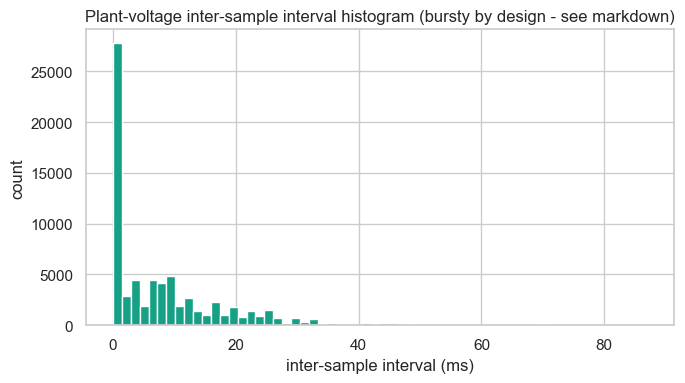

In [26]:
plant_events = sorted([e for e in events if e.get("sensor") == "plant_voltage"], key=lambda e: e["ts"])
plant_ts = np.array([e["ts"] for e in plant_events], dtype=np.int64)
plant_val = np.array([e["value"] for e in plant_events], dtype=float)
dt_ms = np.diff(plant_ts).astype(float)

# Throughput-based measurement (samples / total span), robust to bursty
# packet delivery - see markdown above for why a raw median of consecutive
# gaps is not usable here.
plant_span_s = (plant_ts[-1] - plant_ts[0]) / 1000.0 if plant_ts.size > 1 else np.nan
measured_fs = (plant_ts.size - 1) / plant_span_s if plant_ts.size > 1 else np.nan
deviation = abs(measured_fs - PLANT_FS_NOMINAL_HZ) / PLANT_FS_NOMINAL_HZ

print(f"Plant samples             : {plant_ts.size}")
print(f"Plant signal span         : {plant_span_s:.1f} s (session duration: {SESSION_DURATION_S:.1f} s)")
print(f"Measured sampling rate    : {measured_fs:.2f} Hz (samples / span)")
print(f"Configured nominal rate   : {PLANT_FS_NOMINAL_HZ:.2f} Hz")
print(f"Deviation                 : {100*deviation:.1f}% (tolerance {100*PLANT_FS_TOLERANCE:.0f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(dt_ms, bins=60, color="#16a085")
ax.set_xlabel("inter-sample interval (ms)"); ax.set_ylabel("count")
ax.set_title("Plant-voltage inter-sample interval histogram (bursty by design - see markdown)")
plt.tight_layout(); plt.show()

if deviation > PLANT_FS_TOLERANCE:
    raise RuntimeError(
        f"Measured plant sampling rate ({measured_fs:.2f} Hz) deviates from the configured "
        f"nominal ({PLANT_FS_NOMINAL_HZ:.2f} Hz) by {100*deviation:.1f}%, exceeding the "
        f"{100*PLANT_FS_TOLERANCE:.0f}% tolerance. Refusing to window the plant signal at a "
        "rate that does not match what was actually measured - update PLANT_FS_NOMINAL_HZ only "
        "after confirming which rate is correct for this session/firmware version.")
PLANT_TRUE_FS = measured_fs

**CO2, environment only - not a label input.** The setup also streams
ambient CO2 (ppm) alongside the plant voltage. It is not used anywhere in
the label rule or the ML export; it is plotted in Section 4.13 purely as
context for reading the plant-voltage timeline (e.g. a rising CO2 trace
from the participant's own breathing in a small room is a plausible
confound for slow plant-voltage drift, and is worth being able to see).

In [27]:
co2_events = sorted([e for e in events if e.get("sensor") == "co2"], key=lambda e: e["ts"])
co2_ts = np.array([e["ts"] for e in co2_events], dtype=np.int64)
co2_val = np.array([e["value"] for e in co2_events], dtype=float)
if co2_ts.size:
    print(f"CO2 samples: {co2_ts.size}  range: {co2_val.min():.0f}-{co2_val.max():.0f} ppm  "
          f"mean: {co2_val.mean():.0f} ppm")
else:
    print("No co2 events in this session - CO2 row will be omitted from the timeline plot.")

CO2 samples: 1424  range: 723-1206 ppm  mean: 923 ppm


In [28]:
_trapz = getattr(np, "trapezoid", None) or np.trapz

def extract_plant_features(volts, fs=None):
    fs = fs if fs is not None else PLANT_TRUE_FS
    out = {}
    v = np.asarray(volts, dtype=float)
    n = v.size
    out["plant_n_samples"] = int(n)

    if n == 0:
        for k in ["plant_mean", "plant_median", "plant_std", "plant_iqr", "plant_min", "plant_max",
                  "plant_range", "plant_rms", "plant_zcr", "plant_sat_pos_frac", "plant_sat_neg_frac",
                  "bp_0_1", "bp_1_5", "bp_5_15", "bp_15_30", "band_power_sum"]:
            out[k] = np.nan
        out["plant_const_flag"] = False
        out["plant_quality"] = "dead_flat"
        out["plant_dead_flag"] = True
        out["plant_suspect_flag"] = False
        return out

    # ── Mains notch (50 Hz), time-domain stats only ──────────────────────
    # ~49-50Hz carries 66-73% of the raw signal's total power on every real
    # session checked (see markdown above) - a plant_std computed on the raw
    # signal is mostly a mains-hum statistic, not a plant one. We remove it
    # here, before any time-domain stat is computed, with a zero-phase
    # filter (sosfiltfilt) so it does not shift sample values in time.
    # Saturation diagnostics below deliberately stay on the untouched raw
    # signal - a linear notch filter is not trustworthy right at the ADC
    # rails - and the spectral computation further below also stays on the
    # raw-derived signal, since Welch needs to see the real spectrum
    # (including the 30-50Hz band we deliberately drop) to be faithful.
    if n >= 32 and fs and fs > 2 * MAINS_HZ + 4:
        _sos = sp_signal.butter(4, [MAINS_HZ - 4, MAINS_HZ + 4], btype="bandstop", fs=fs, output="sos")
        v_td = sp_signal.sosfiltfilt(_sos, v)
    else:
        v_td = v

    mean = float(np.mean(v_td)); median = float(np.median(v_td))
    std = float(np.std(v_td, ddof=1)) if n > 1 else 0.0
    q75, q25 = np.percentile(v_td, [75, 25]); iqr = float(q75 - q25)
    vmin, vmax = float(np.min(v_td)), float(np.max(v_td)); rng_ = float(vmax - vmin)
    rms = float(np.sqrt(np.mean(v_td ** 2)))
    vd_td = v_td - mean
    zcr = float(np.mean(np.abs(np.diff(np.sign(vd_td))) > 0)) if n > 1 else 0.0
    out.update(plant_mean=round(mean, 6), plant_median=round(median, 6), plant_std=round(std, 6),
               plant_iqr=round(iqr, 6), plant_min=round(vmin, 6), plant_max=round(vmax, 6),
               plant_range=round(rng_, 6), plant_rms=round(rms, 6), plant_zcr=round(zcr, 6))

    # Saturation diagnostics: raw signal, deliberately not notch-filtered.
    sat_pos = float(np.mean(v >= ADC_VREF - 1e-3)); sat_neg = float(np.mean(v <= 1e-3))
    out.update(plant_sat_pos_frac=round(sat_pos, 4), plant_sat_neg_frac=round(sat_neg, 4),
               plant_const_flag=bool(np.all(v == v[0])))

    # Spectral: raw-derived, unaffected by the notch above.
    vd = v - float(np.mean(v))
    if n >= 16 and float(np.std(v)) > 0:
        nper = min(256, n)
        f, pxx = sp_signal.welch(vd, fs=fs, window="hann", nperseg=nper, scaling="density")
        def band(lo, hi):
            m = (f >= lo) & (f < hi)
            return float(_trapz(pxx[m], f[m])) if m.any() else 0.0
        bp_0_1, bp_1_5, bp_5_15, bp_15_30 = band(0, 1), band(1, 5), band(5, 15), band(15, 30)
        # 30-50 Hz band intentionally dropped: sits on 50 Hz mains interference at this fs
        band_power_sum = bp_0_1 + bp_1_5 + bp_5_15 + bp_15_30
    else:
        bp_0_1 = bp_1_5 = bp_5_15 = bp_15_30 = band_power_sum = np.nan
    out.update(bp_0_1=bp_0_1, bp_1_5=bp_1_5, bp_5_15=bp_5_15, bp_15_30=bp_15_30,
               band_power_sum=band_power_sum)

    lsb = ADC_VREF / 4096.0
    std_counts = std / lsb if lsb else float("inf")
    if sat_pos > 0.95 or sat_neg > 0.95:
        q = "dead_saturated"
    elif std < PLANT_DEAD_VOLTAGE_THRESHOLD:
        q = "dead_flat"
    elif std_counts < 5:
        q = "dead_flat"
    elif (sat_pos + sat_neg) > 0.20:
        q = "suspect_clipped"
    elif std_counts < 10:
        q = "suspect_lowamp"
    else:
        q = "ok"
    out["plant_quality"] = q
    out["plant_dead_flag"] = q.startswith("dead")
    out["plant_suspect_flag"] = q.startswith("suspect")
    return out


def add_plant_features(df):
    rows = []
    for r in df.itertuples():
        m = (plant_ts >= r.win_start_ms) & (plant_ts < r.win_end_ms)
        rows.append(extract_plant_features(plant_val[m]))
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(rows)], axis=1)


ml_df = add_plant_features(ml_df)
analysis_df = add_plant_features(analysis_df)

print("Plant quality distribution (ML grid):")
print(ml_df["plant_quality"].value_counts())

PLANT_COLS = ["plant_n_samples", "plant_mean", "plant_median", "plant_std", "plant_iqr", "plant_min",
              "plant_max", "plant_range", "plant_rms", "plant_zcr", "plant_sat_pos_frac",
              "plant_sat_neg_frac", "plant_const_flag", "bp_0_1", "bp_1_5", "bp_5_15", "bp_15_30",
              "band_power_sum", "plant_quality", "plant_dead_flag", "plant_suspect_flag"]

ml_export = finalize_export(ml_df, PARTICIPANT_ID, SESSION_ID)
ml_export = pd.concat([ml_export, ml_df[PLANT_COLS].reset_index(drop=True)], axis=1)
overlap_export = finalize_export(analysis_df, PARTICIPANT_ID, SESSION_ID)
overlap_export = pd.concat([overlap_export, analysis_df[PLANT_COLS].reset_index(drop=True)], axis=1)

ml_export.to_csv(OUT_ML_CSV, index=False)
overlap_export.to_csv(OUT_OVERLAP_CSV, index=False)
print(f"\nRe-saved with plant features: {OUT_ML_CSV} ({ml_export.shape[1]} columns), "
      f"{OUT_OVERLAP_CSV} ({overlap_export.shape[1]} columns)")

Plant quality distribution (ML grid):
plant_quality
ok    20
Name: count, dtype: int64

Re-saved with plant features: ..\data\sessions\2026-07-06_19-51_proband_15\labelled_windows_ml.csv (52 columns), ..\data\sessions\2026-07-06_19-51_proband_15\labelled_windows_overlapping.csv (51 columns)


## 4.13 Visualisation

A session timeline (RMSSD, HR, FER valence/arousal, plant voltage with CO2
overlaid, and the label bar), a Russell circumplex (1980) scatter of FER
valence/arousal coloured by label and marked by agreement category, the
overall label composition, and the confidence distribution.

The plant-voltage row uses the anti-aliased 1 Hz signal from
`scipy.signal.resample_poly` (§4.12), not a raw interpolation. Its visible
range is narrow (roughly 1.41-1.49 V on a typical session here) compared to
the raw stream (roughly 1.32-1.60 V) - that is the anti-aliasing filter
doing its job, not a bug: most of the raw signal's swing is content above
about 0.5 Hz (the Nyquist frequency of a 1 Hz grid), which a proper low-pass
removes before decimating. A naive `np.interp` onto the same 1 Hz grid (what
an earlier version of this pipeline did) looks more "dynamic" only because
it aliases that higher-frequency content into what appear to be larger
slow swings, rather than filtering it out. The per-window plant features
used for the ML export (§4.12) are computed on the raw, undecimated signal,
so this visualisation choice does not affect them either way - it only
affects what this one plot looks like.

In [ ]:
# ── Anti-aliased 1 Hz plant-voltage grid, for the timeline plot only ────
# resample_poly(up=1, down=_down) maps output sample k to (approximately)
# input sample k*_down; we read the REAL timestamp of that input sample
# directly rather than assuming a constant rate, so the time axis is
# correct even though the raw stream arrives in bursts (§4.12).
# padtype="line" (default is "constant", i.e. zero-padding): the plant
# voltage sits around 1.4 V, nowhere near zero, so zero-padding the FIR
# filter's edges pulls the first/last decimated samples down toward 0 V -
# a filter artefact, not a real reading. "line" extrapolates from the
# signal's own edge trend instead, which keeps the endpoints physical.
_down = max(1, int(round(PLANT_TRUE_FS)))
if plant_val.size > _down * 2:
    plant_1hz = sp_signal.resample_poly(plant_val, up=1, down=_down, padtype="line")
    _out_idx = np.clip(np.arange(plant_1hz.size) * _down, 0, plant_val.size - 1)
    plant_1hz_t_s = (plant_ts[_out_idx] - T0_MS) / 1000.0
else:
    plant_1hz, plant_1hz_t_s = plant_val, (plant_ts - T0_MS) / 1000.0

label_col = {"positive-activated": "#2ecc71", "positive-calm": "#1e8449",
            "negative-activated": "#e74c3c", "negative-calm": "#943126",
            "neutral": "#7f8c8d", "excluded": "#bdc3c7"}

fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)

def t_min(ts_array):
    return (np.asarray(ts_array) - T0_MS) / 60_000

for ax in axes:
    ax.axvspan(0, BASELINE_S / 60, alpha=0.10, color="#aaaaaa", zorder=0)
    ax.axvline(BASELINE_S / 60, color="#888", lw=0.8, ls="--")

axes[0].plot(t_min(ml_df.win_start_ms), ml_df.rmssd, color="#c0392b", lw=1.2, marker="o", ms=3)
axes[0].axhline(CALIB["median_rmssd"], color="gray", lw=0.8, ls=":", label="session median")
axes[0].set_ylabel("RMSSD (ms)"); axes[0].legend(fontsize=8)
axes[0].set_title("Session timeline (grey = baseline | bar opacity = confidence)")

axes[1].plot(t_min(ml_df.win_start_ms), ml_df.mean_hr, color="#2980b9", lw=1.2, marker="o", ms=3)
axes[1].axhline(CALIB["median_hr"], color="gray", lw=0.8, ls=":", label="session median")
axes[1].set_ylabel("HR (bpm)"); axes[1].legend(fontsize=8)

axes[2].plot(t_min(ml_df.win_start_ms), ml_df.fer_valence, color="#27ae60", lw=1.2, label="valence")
axes[2].plot(t_min(ml_df.win_start_ms), ml_df.fer_arousal, color="#e67e22", lw=1.0, alpha=0.7, label="arousal")
axes[2].axhline(0, color="gray", lw=0.5); axes[2].legend(fontsize=8)
axes[2].set_ylabel("FER [-1,+1]")

axes[3].plot(plant_1hz_t_s / 60, plant_1hz, color="#16a085", lw=0.8, label="plant voltage")
axes[3].set_ylabel("Plant voltage (V)", color="#16a085")
axes[3].tick_params(axis="y", labelcolor="#16a085")
if co2_ts.size:
    ax3b = axes[3].twinx()
    ax3b.plot(t_min(co2_ts), co2_val, color="#8e44ad", lw=0.8, alpha=0.8, label="CO2")
    ax3b.set_ylabel("CO2 (ppm)", color="#8e44ad")
    ax3b.tick_params(axis="y", labelcolor="#8e44ad")

for r in ml_df.itertuples():
    ts = (r.win_start_ms - T0_MS) / 60_000
    axes[4].barh(0, WIN_S / 60, left=ts, height=0.8, color=label_col.get(r.label, "#bdc3c7"),
                 alpha=0.3 + 0.7 * r.label_confidence)
axes[4].set_yticks([]); axes[4].set_ylabel("Label"); axes[4].set_xlabel("Time (min)")
patches = [mpatches.Patch(color=c, label=l) for l, c in label_col.items()]
axes[4].legend(handles=patches, loc="upper right", fontsize=8)

plt.tight_layout(); plt.show()

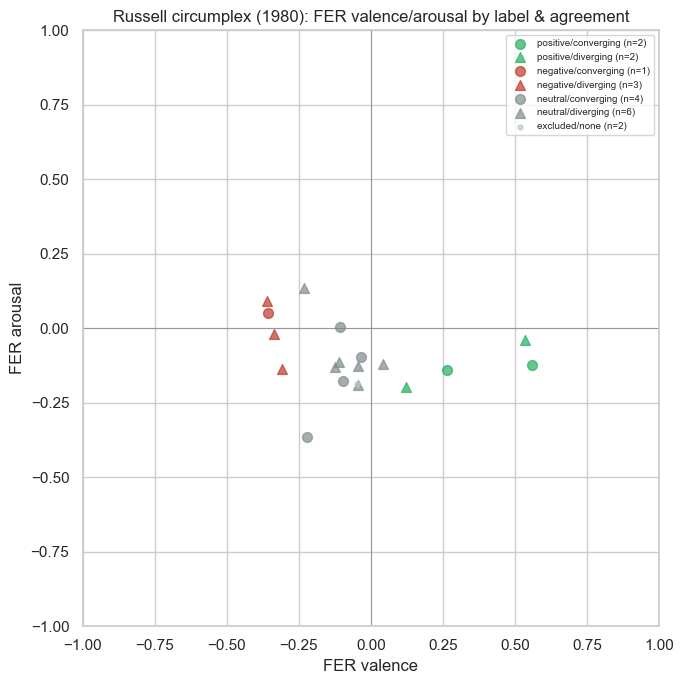

In [30]:
# ── Russell circumplex (1980) ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
marker = {"converging": "o", "diverging": "^", "none": "."}
for lab, c in label_col.items():
    for agr, mk in marker.items():
        sub = ml_df[(ml_df.label == lab) & (ml_df.agreement == agr)]
        if len(sub):
            ax.scatter(sub["fer_valence"], sub["fer_arousal"], color=c, marker=mk, alpha=0.7, s=50,
                      label=f"{lab}/{agr} (n={len(sub)})")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
ax.set_xlabel("FER valence"); ax.set_ylabel("FER arousal")
ax.set_title("Russell circumplex (1980): FER valence/arousal by label & agreement")
ax.legend(fontsize=7, loc="best"); plt.tight_layout(); plt.show()

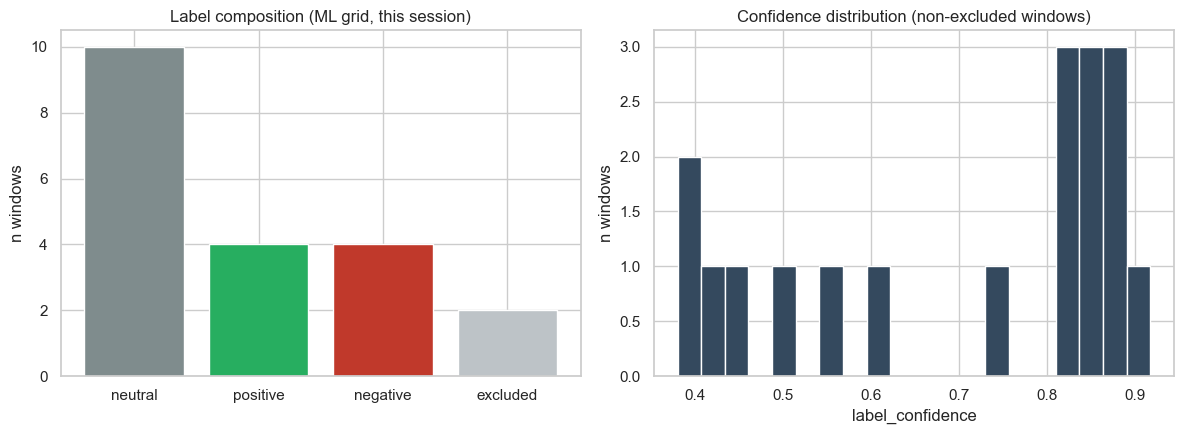

In [31]:
# ── Overall label composition + confidence distribution ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

counts = ml_df["label"].value_counts()
axes[0].bar(counts.index, counts.values, color=[label_col.get(l, "#bdc3c7") for l in counts.index])
axes[0].set_ylabel("n windows"); axes[0].set_title("Label composition (ML grid, this session)")

axes[1].hist(ml_df.loc[ml_df.label != "excluded", "label_confidence"], bins=20, color="#34495e")
axes[1].set_xlabel("label_confidence"); axes[1].set_ylabel("n windows")
axes[1].set_title("Confidence distribution (non-excluded windows)")

plt.tight_layout(); plt.show()

## 4.14 Limitations

- **No self-report.** This is a **proxy label**, not ground truth. The
  accuracy of these labels against what the participant actually felt is
  unknown. Section 4.11 explains how to close this gap.
- **Facial expression can be suppressed.** Valence comes entirely from the
  face. A participant who felt something without showing it will be
  labelled "neutral" — the label reflects visible expression, not
  necessarily inner state.
- **HSEmotion is an imperfect direction estimator.** 61.93% accuracy on
  AffectNet (8 classes; EmotiEffLib repository model table). It is a
  reasonable, but not reliable, single-window classifier.
- **Respiration was not recorded.** Respiration rate and volume change
  RMSSD without changing vagal tone (Shaffer & Ginsberg, 2017). This is the
  largest uncontrolled confounder in the arousal axis, and we have no way to
  quantify its size in this dataset.
- **Ultra-short-term HRV is not interchangeable with 5-min or 24-h HRV**
  (Shaffer & Ginsberg, 2017). Every RMSSD value in this notebook is a
  30-second estimate, a statistically different quantity from the values
  most of the HRV literature reports.
- **No stimulus-based or between-participant validation.** This pipeline
  does not use any information about video-clip structure or timing (see
  the scope note in §4.0). A between-participant "did everyone react the
  same way to the same stimulus at the same time" check — which would have
  been the strongest test this kind of data could support — is therefore
  not available. Section 4.10's V0/V1/V3 only establish within-pipeline
  internal consistency, which is weaker evidence than a stimulus-locked
  consistency check would be.
- **The arousal axis rests partly on a weak, contested signal.**
  Ultra-short-term HRV's value as an arousal indicator is itself disputed:
  Schippers et al. (2018), using the same RMSSD/30s-window/IAPS design as
  this notebook, found no valence-related RMSSD difference at all, and Gu
  et al. (2023) found ultra-short-window time-domain HRV metrics often miss
  real condition differences generally. `arousal_combined` fuses this
  signal with FER arousal rather than relying on it alone, but that
  fusion's value is tested in Section 4.10 (V0) on this project's own
  pooled data, not assumed, and the current fallback (fused vs. FER-only)
  can change as more sessions are added.
- **The plant-voltage channel's physiological validity could not be
  confirmed, and this is now permanent.** Every real session's raw plant
  signal was dominated (66-73% of total power) by a ~49-50Hz peak matching
  mains interference, which the firmware's on-board filter does not remove
  and which §4.12 (points 5-6) now notches out of the time-domain features.
  Two 60-second reference captures taken with nobody in the room show the
  sensor *can* detect a large (32x), low-frequency, non-mains signal when
  the plant is connected — the most encouraging evidence in this
  investigation — but the firmware has no active mains-cancellation circuit
  (no right-leg-drive), and every real session had a participant sitting
  next to the unshielded electrodes for ten minutes, which is a
  mechanistically sufficient explanation for the contamination on its own.
  Whether the broadband content remaining in the real sessions after the
  mains notch is plant physiology, participant-proximity interference, or a
  mix, cannot be determined from the data that exists. **The plant sensor
  and the plant itself are no longer available, so this cannot be
  re-tested** — any downstream use of `plant_*` features should treat them
  as being of unconfirmed physiological validity, not as a settled
  measurement.
- **Small sample.** Session counts in this dataset are small; none of the
  statistics above support strong claims about generalisation across
  people.
- **Pragmatic parameters.** `K_TAU` and the confidence weights `W1..W4`
  are engineering choices, not values taken from a source; the arousal
  split itself is a median and needs no analogous threshold. Section 4.10
  (V4) is the record of how much the results depend on `K_TAU`.

## 4.15 References

1. Task Force of the European Society of Cardiology and the North American
   Society of Pacing and Electrophysiology (1996). Heart rate variability:
   standards of measurement, physiological interpretation, and clinical use.
   *Circulation*, 93(5), 1043-1065.
2. Shaffer, F., & Ginsberg, J. P. (2017). An Overview of Heart Rate
   Variability Metrics and Norms. *Frontiers in Public Health*, 5, 258.
   doi:10.3389/fpubh.2017.00258
3. Baek, H. J., Cho, C.-H., Cho, J., & Woo, J.-M. (2015). Reliability of
   Ultra-Short-Term Analysis as a Surrogate of Standard 5-Min Analysis of
   Heart Rate Variability. *Telemedicine and e-Health*, 21(5), 404-414.
   doi:10.1089/tmj.2014.0104
4. Kreibig, S. D. (2010). Autonomic nervous system activity in emotion: A
   review. *Biological Psychology*, 84(3), 394-421.
   doi:10.1016/j.biopsycho.2010.03.010
5. Choi, K.-H., Kim, J., Kwon, O. S., Kim, M. J., Ryu, Y. H., & Park, J.-E.
   (2017). Is heart rate variability (HRV) an adequate tool for evaluating
   human emotions? - A focus on the use of the International Affective
   Picture System (IAPS). *Psychiatry Research*, 251, 192-196.
   doi:10.1016/j.psychres.2017.02.025
6. Schneider, M., Rominger, C., & Schwerdtfeger, A. R. (2025). Associations
   Between Positive Affect and Heart Rate Variability: A Systematic Review.
   *Current Cardiology Reports*. doi:10.1007/s11886-025-02299-4
7. Russell, J. A. (1980). A circumplex model of affect. *Journal of
   Personality and Social Psychology*, 39(6), 1161-1178.
8. Mollahosseini, A., Hasani, B., & Mahoor, M. H. (2019). AffectNet: A
   Database for Facial Expression, Valence, and Arousal Computing in the
   Wild. *IEEE Transactions on Affective Computing*, 10(1), 18-31.
   doi:10.1109/TAFFC.2017.2740923
9. Savchenko, A. V. (2022). HSEmotion: High-speed emotion recognition
   library. *Software Impacts*, 5, 100433. doi:10.1016/j.simpa.2022.100433
10. Savchenko, A. V. (2022). Frame-level Prediction of Facial Expressions,
    Valence, Arousal and Action Units for Mobile Devices. arXiv:2203.13436
    (CVPR 2022 ABAW Workshop).
11. EmotiEffLib (ex-HSEmotion) repository, model table under "Details":
    github.com/sb-ai-lab/EmotiEffLib
12. Soleymani, M., Asghari-Esfeden, S., Fu, Y., & Pantic, M. (2016).
    Analysis of EEG Signals and Facial Expressions for Continuous Emotion
    Detection. *IEEE Transactions on Affective Computing*, 7(1), 17-28.
13. Lipponen, J. A., & Tarvainen, M. P. (2019). A robust algorithm for heart
    rate variability time series artefact correction using novel beat
    classification. *Journal of Medical Engineering & Technology*, 43(3),
    173-181. doi:10.1080/03091902.2019.1640306
14. Makowski, D., Pham, T., Lau, Z. J., Brammer, J. C., Lespinasse, F., Pham,
    H., Scholzel, C., & Chen, S. H. A. (2021). NeuroKit2: A Python toolbox
    for neurophysiological signal processing. *Behavior Research Methods*,
    53(4), 1689-1696.
15. Gilgen-Ammann, R., Schweizer, T., & Wyss, T. (2019). RR interval signal
    quality of a heart rate monitor and an ECG Holter at rest and during
    exercise. *European Journal of Applied Physiology*, 119(7), 1525-1532.
    doi:10.1007/s00421-019-04142-5
16. Schaffarczyk, M., Rogers, B., Reer, R., & Gronwald, T. (2022). Validity
    of the Polar H10 Sensor for Heart Rate Variability Analysis during
    Resting State and Incremental Exercise in Recreational Men and Women.
    *Sensors*, 22(17), 6536. doi:10.3390/s22176536
17. Bradley, M. M., & Lang, P. J. (1994). Measuring emotion: The
    Self-Assessment Manikin and the semantic differential. *Journal of
    Behavior Therapy and Experimental Psychiatry*, 25(1), 49-59.
    doi:10.1016/0005-7916(94)90063-9
18. Schippers, A., Aben, B., Griep, Y., & Van Overwalle, F. (2018).
    Ultra-short term heart rate variability as a tool to assess changes in
    valence. *Psychiatry Research*, 270, 517-522.
    doi:10.1016/j.psychres.2018.10.005
19. Gu, Z., Zarubin, V., & Martsberger, C. (2023). The effectiveness of time
    domain and nonlinear heart rate variability metrics in ultra-short time
    series. *Physiological Reports*, 11(22), e15863. doi:10.14814/phy2.15863